# Multimodal Deep Learning for Anaemia Classification
## Extended experiments — expanded model set, metrics and diagnostics

**Shehnaz — 3023411** · MSc Dissertation · CN7000 · University of East London

### Model inventory

| Arm | Models |
|---|---|
| 1 — Clinical (CBC) | Logistic Regression, Random Forest, XGBoost, SVM, MLP |
| 2 — Image | EfficientNetB0, ResNet-50, DenseNet121, MobileNetV2 |
| 3 — Fusion | Feature-level (concatenation), Late fusion (stacked) |


---
# 1. Setup and configuration

In [2]:
import os, re, io, csv, json, time, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

CFG = {
    'data_dir'   : '/kaggle/input/datasets/shehnaz0001/anerbc-dataset',
    'version'    : 'AneRBC-II',
    'img_size'   : 224,
    'batch_size' : 32,
    'test_frac'  : 0.20,
    'val_frac'   : 0.15,
    'head_epochs': 15,
    'fine_epochs': 15,
    'head_lr'    : 1e-3,
    'fine_lr'    : 1e-5,
    'unfreeze'   : 40,
    'dropout'    : 0.3,
    'patience'   : 5,
    'cbc'        : ['HGB','RBC','HCT','MCV','MCH','MCHC','RDW_CV','PLT','WBC'],
    'mlp_units'  : [64, 32],
}

DATA_DIR = Path(CFG['data_dir'])
OUT = Path('/kaggle/working'); OUT.mkdir(exist_ok=True)
IMG_EXT = {'.png','.jpg','.jpeg','.tif','.tiff','.bmp'}

# consistent house style for every figure
PALETTE = {'deep':'#1F5E63','mid':'#57867E','sage':'#8FAF9A','pale':'#B8CDBE',
           'ink':'#2E3A3C','grey':'#8E8B82','cream':'#E8E6DF'}
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,
                     'axes.edgecolor':'#D2CFC6','axes.labelcolor':PALETTE['ink'],
                     'xtick.color':PALETTE['ink'],'ytick.color':PALETTE['ink'],
                     'text.color':PALETTE['ink'],'figure.facecolor':'white',
                     'axes.grid':True,'grid.color':'#EDEBE5','grid.linewidth':0.8})

print('TensorFlow', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus[0].name if gpus else 'NONE — enable the accelerator')
assert DATA_DIR.exists(), 'Dataset not found under /kaggle/input'
print('Data:', DATA_DIR)

TensorFlow 2.20.0
GPU: /physical_device:GPU:0
Data: /kaggle/input/datasets/shehnaz0001/anerbc-dataset


---
# 2. Data preparation

Identical to the main experiment: masks excluded, patient identifiers derived so that AneRBC-I
slides and their twelve AneRBC-II tiles resolve to one patient, CBC reports parsed and
canonicalised, and the split performed by patient so no specimen appears on both sides.

In [2]:
def patient_id(stem):
    s = stem.strip()
    m = re.match(r'^(\d+)_(\d+)_([ah])$', s)
    if m: return f'{int(m.group(1))}_{m.group(3)}'
    m = re.match(r'^(\d+)_([ah])$', s)
    if m: return f'{int(m.group(1))}_{m.group(2)}'
    return s

rows = []
for p in DATA_DIR.rglob('*'):
    if p.suffix.lower() not in IMG_EXT: continue
    parts = [x.lower() for x in p.relative_to(DATA_DIR).parts]
    if 'original_images' not in parts: continue
    if   any('anemic'  in x for x in parts): label = 'Anaemic'
    elif any('healthy' in x for x in parts): label = 'Healthy'
    else: continue
    version = ('AneRBC-II' if 'anerbc-ii' in parts else
               'AneRBC-I'  if 'anerbc-i'  in parts else None)
    rows.append({'path':str(p),'file':p.name,'label':label,
                 'version':version,'patient':patient_id(p.stem)})

images = pd.DataFrame(rows).sort_values('path').reset_index(drop=True)
print(f'{len(images):,} images from {images.patient.nunique():,} patients')

# The raw index contains AneRBC-I and AneRBC-II. All modelling and model-facing figures use
# AneRBC-II only; keeping this explicit prevents accidental 13,000-image summaries.
model_images = images.loc[images.version == CFG['version']].copy().reset_index(drop=True)
assert len(model_images) == 12_000, f'Expected 12,000 AneRBC-II images, found {len(model_images):,}'
assert model_images.patient.nunique() == 1_000
assert model_images.groupby('patient').size().eq(12).all()
print(f'Modelling subset: {len(model_images):,} images, '
      f'{model_images.patient.nunique():,} patients, 12 tiles per patient')

# ---- audit output for the dissertation (Output 3.2) ----
print()
print(images.groupby(['version', 'label']).size().to_frame('images').to_string())
print()
print('file name to patient mapping (sample):')
for _, r in images.groupby('version', group_keys=False).head(2).iterrows():
    print(f"  {r['file']}  ({r['version']})  ->  patient {r['patient']}")
print()
print(f"masks and non-original files excluded; "
      f"{images.version.eq('AneRBC-II').sum():,} of the {len(images):,} indexed images are AneRBC-II")


13,000 images from 1,000 patients
Modelling subset: 12,000 images, 1,000 patients, 12 tiles per patient

                   images
version   label          
AneRBC-I  Anaemic     500
          Healthy     500
AneRBC-II Anaemic    6000
          Healthy    6000

file name to patient mapping (sample):
  001_a.png  (AneRBC-I)  ->  patient 1_a
  002_a.png  (AneRBC-I)  ->  patient 2_a
  0001_01_a.png  (AneRBC-II)  ->  patient 1_a
  0001_02_a.png  (AneRBC-II)  ->  patient 1_a

masks and non-original files excluded; 12,000 of the 13,000 indexed images are AneRBC-II


In [3]:
# ---- CBC extraction and cleaning ----
def parse_cbc(path):
    out = {}
    try: text = Path(path).read_text(encoding='utf-8', errors='ignore')
    except Exception: return out
    for row in csv.reader(io.StringIO(text)):
        if len(row) < 2: continue
        name = row[0].strip().upper()
        if not name or name.startswith('TEST'): continue
        m = re.search(r'[-+]?\d*\.?\d+', row[1].replace('*',' '))
        if m:
            try: out[name] = float(m.group())
            except ValueError: pass
    return out

GREEK = str.maketrans({'\u039c':'M','\u039f':'O','\u0391':'A','\u0392':'B','\u0395':'E',
                       '\u0397':'H','\u0399':'I','\u039a':'K','\u039d':'N','\u03a1':'P',
                       '\u03a4':'T','\u03a5':'Y','\u03a7':'X'})
SYN = {'HEMOGLOBIN':'HGB','HAEMOGLOBIN':'HGB','HB':'HGB','NEUTROPHIL':'NEUT',
       'NEUTROPHILS':'NEUT','LYMPHOCYTE':'LYMP','LYMPHOCYTES':'LYMP','LYM':'LYMP',
       'MONOCYTE':'MONO','MONOCYTES':'MONO','EOSINOPHIL':'EOS','EOSINOPHILS':'EOS',
       'SEOS':'EOS','BASOPHIL':'BASO','BASOPHILS':'BASO','RASO':'BASO',
       'RDW':'RDW_CV','RDWCV':'RDW_CV','PLTX':'PLT'}

def canon(name):
    n = str(name).upper().translate(GREEK).strip()
    if re.match(r'^\d', n): return None
    absol = n.startswith('ABS_') or n.startswith('#')
    n = re.sub(r'^(ABS_|#)','',n); n = re.sub(r'^[%$&*\s]+','',n)
    n = re.sub(r'X10\.E.*$','',n); n = re.sub(r'\d.*$','',n)
    n = re.sub(r'[^A-Z_]','',n).strip('_'); n = SYN.get(n,n)
    return None if len(n) < 2 else (('ABS_'+n) if absol else n)

cbc_files = [p for p in DATA_DIR.rglob('*.txt') if 'cbc' in p.parent.name.lower()]
raw = []
for p in cbc_files:
    parts = [x.lower() for x in p.relative_to(DATA_DIR).parts]
    if   any('anemic'  in x for x in parts): lab = 'Anaemic'
    elif any('healthy' in x for x in parts): lab = 'Healthy'
    else: continue
    v = parse_cbc(p)
    if v: v.update({'patient':patient_id(p.stem),'label':lab}); raw.append(v)

cbc_raw = pd.DataFrame(raw).drop_duplicates(subset=['patient']).reset_index(drop=True)

# --- AUDIT 1: haemoglobin coverage BEFORE canonicalisation -------------------
# Only the column literally named 'HGB' is available before synonyms are resolved.
n_patients_raw = len(cbc_raw)
hgb_before = (cbc_raw['HGB'].notna().mean() * 100) if 'HGB' in cbc_raw.columns else 0.0

groups = defaultdict(list)
discarded_names = []
for c in cbc_raw.columns:
    if c in ('patient','label'): continue
    k = canon(c)
    if k: groups[k].append(c)
    else: discarded_names.append(c)

cbc = cbc_raw[['patient','label']].copy()
for k, srcs in groups.items():
    cbc[k] = cbc_raw[srcs].apply(pd.to_numeric, errors='coerce').bfill(axis=1).iloc[:,0]

# --- AUDIT 2: count values removed by the physiological range checks ---------
RANGES = {'HGB':(3,20),'RBC':(1,8),'HCT':(10,60),'MCV':(40,130),'MCH':(10,45),
          'MCHC':(20,40),'RDW_CV':(8,45),'PLT':(5,1500),'WBC':(0.5,60)}
range_removed = {}
for col,(lo,hi) in RANGES.items():
    if col in cbc.columns:
        before = cbc[col].notna().sum()
        cbc.loc[~cbc[col].between(lo,hi), col] = np.nan
        range_removed[col] = int(before - cbc[col].notna().sum())
n_range_removed = sum(range_removed.values())

FEATURES = [f for f in CFG['cbc'] if f in cbc.columns]
hgb_after = cbc['HGB'].notna().mean() * 100 if 'HGB' in cbc.columns else 0.0

# ---- Output 3.4: the canonicalisation audit quoted in the dissertation ------
print(f'{cbc_raw.shape[1]-2} raw names -> {len(groups)} canonical; using {len(FEATURES)} indices')
print(f'{len(cbc)} patients with CBC data')
print()
print('examples of names collapsed onto one canonical test:')
collapsed = {k: v for k, v in groups.items() if len(v) > 1}
for k in sorted(collapsed, key=lambda k: -len(collapsed[k]))[:6]:
    print(f'  {k:<9s} <- ' + ', '.join(sorted(collapsed[k])))
print(f'  ({len(collapsed)} canonical tests were formed from more than one raw name)')
print()
print('discarded as transcription errors: ' +
      (', '.join(repr(d) for d in discarded_names[:6]) if discarded_names else 'none'))
print(f'  ({len(discarded_names)} raw column names discarded in total)')
print()
print(f'{n_range_removed} values removed by physiological range checks')
print('  by index: ' + ', '.join(f'{k}={v}' for k, v in range_removed.items() if v))
print()
print(f'haemoglobin coverage: {hgb_before:.1f}% -> {hgb_after:.1f}% of patients')

# machine-readable copy so the dissertation can cite a file rather than a screenshot
pd.DataFrame([{'raw_names': cbc_raw.shape[1]-2, 'canonical_tests': len(groups),
               'indices_used': len(FEATURES), 'patients': len(cbc),
               'range_check_removals': n_range_removed,
               'hgb_coverage_before_pct': round(hgb_before, 1),
               'hgb_coverage_after_pct': round(hgb_after, 1),
               'discarded_raw_names': len(discarded_names)}]
            ).to_csv(OUT/'cleaning_audit.csv', index=False)


70 raw names -> 20 canonical; using 9 indices
1000 patients with CBC data

examples of names collapsed onto one canonical test:
  MONO      <- $MONO, %MONO, &MONO, *MONO, MONO, MONOCYTE, MONOCYTES, ΜΟΝΟ
  RDW_CV    <- $RDW---CV, %RDW---CV, %RDW-CV, &RDW---CV, RDW---CV, RDW-CV
  NEUT      <- $NEUT, %NEUT, &NEUT, NEUT, NEUTROPHIL, NEUTROPHILS
  LYMP      <- $LYMP, %LYMP, &LYMP, LYMP, LYMPHOCYTE, LYMPHOCYTES
  EOS       <- $EOS, %EOS, EOS, EOSINOPHIL, EOSINOPHILS, SEOS
  BASO      <- $BASO, %BASO, &BASO, BASO, BASOPHIL
  (13 canonical tests were formed from more than one raw name)

discarded as transcription errors: '#3/ΜL', '0.04 X10.E 3/ΜL', '12.1 G/DL', '14.2 G/DL', '41.6 %'
  (5 raw column names discarded in total)

95 values removed by physiological range checks
  by index: HGB=12, RBC=24, HCT=18, MCV=11, MCH=4, MCHC=10, RDW_CV=8, PLT=3, WBC=5

haemoglobin coverage: 82.0% -> 98.7% of patients


In [3]:
# Output 3.3 — one clinical report exactly as supplied
target = '050_a'
p = next(f for f in DATA_DIR.rglob('*.txt')
         if 'cbc' in f.parent.name.lower() and f.stem == target)
print(p.relative_to(DATA_DIR))
print('-' * 58)
print(p.read_text(encoding='utf-8', errors='ignore')[:700])

AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/CBC_reports/050_a.txt
----------------------------------------------------------
Test,Result/Units,Norm. Range
WBC,* 12.01 x10.e 3/µl,4 --- 10
RBC,4.62 x10.e 6/µl,3.8 --- 4.8
HGB,* 8.4 g/dL,12 --- 15
HCT,* 26.9 %,36 --- 46
MCV,* 58.2 fL,76 --- 96
MCH,* 18.2 pg,27 --- 32
MCHC,31.5 g/dL,31.5 --- 34.5
RDW---CV,* 31.2 %,11.5 --- 14.5
PLT,* 370 x10.e 3/µl,150 --- 450
Neut,* 94.5 %,40 --- 80
LYMP,* 3.7 %,20 --- 40
MONO,* 1.8 %,2 --- 10
EOS,* 0 %,1 --- 6
BASO,0 %,<1
#NEUT,* 11.34 x10.e 3/µl,2 --- 8
#LYMP,* 0.45 x10.e 15 3/µl,0.2 --- 1
#MONO,* 0 x10.e 3/µl,
#EOS,* 0.02 --- 0.5 3/µl,0.002 --- 0.1
#BASO,* 0 x10.e 3/µl,




### Anonymised clinical-data sample for the dissertation

The next cell selects four healthy and four anaemic patients with a fixed random seed, replaces
the source patient identifiers with neutral sample IDs, and displays the nine cleaned CBC indices.
The values are shown **before imputation and scaling**, so any missing measurement is represented
by an em dash. This sample illustrates the input structure only and is not used to estimate model
performance. The cell also exports a 300-dpi PNG and a CSV for insertion into the dissertation.


Anonymised balanced clinical sample: 8 patients (4 per class)
Sample ID   Class  HGB  RBC  HCT  MCV  MCH  MCHC  RDW_CV   PLT   WBC
      P01 Anaemic  9.0 4.93 30.7 62.3 27.0  31.5    19.2 390.0  9.07
      P02 Anaemic  5.9 4.99 25.6 51.3 11.8  23.0       — 511.0 14.75
      P03 Anaemic 15.3 5.36 44.6 83.2 28.5  34.3    12.0 232.0  5.10
      P04 Anaemic 11.0    —    — 63.1 19.3  31.0    30.5 304.0  5.00
      P05 Healthy 15.0 5.32 42.2 79.3 28.2  35.5    15.0 203.0  5.40
      P06 Healthy 10.7 4.44 31.6 71.2 24.1  33.9       — 510.0 14.61
      P07 Healthy 11.9 3.92 35.9 91.6 30.4  33.1    13.2 219.0  3.80
      P08 Healthy 13.7 4.41 39.7 90.0 31.1  34.5    11.5 263.0  5.57


,Sample ID,Class,HGB,RBC,HCT,MCV,MCH,MCHC,RDW_CV,PLT,WBC
0,P01,Anaemic,9.00,4.93,30.70,62.30,27.00,31.50,19.20,390.00,9.07
1,P02,Anaemic,5.90,4.99,25.60,51.30,11.80,23.00,—,511.00,14.75
2,P03,Anaemic,15.30,5.36,44.60,83.20,28.50,34.30,12.00,232.00,5.10
3,P04,Anaemic,11.00,—,—,63.10,19.30,31.00,30.50,304.00,5.00
4,P05,Healthy,15.00,5.32,42.20,79.30,28.20,35.50,15.00,203.00,5.40
5,P06,Healthy,10.70,4.44,31.60,71.20,24.10,33.90,—,510.00,14.61
6,P07,Healthy,11.90,3.92,35.90,91.60,30.40,33.10,13.20,219.00,3.80
7,P08,Healthy,13.70,4.41,39.70,90.00,31.10,34.50,11.50,263.00,5.57


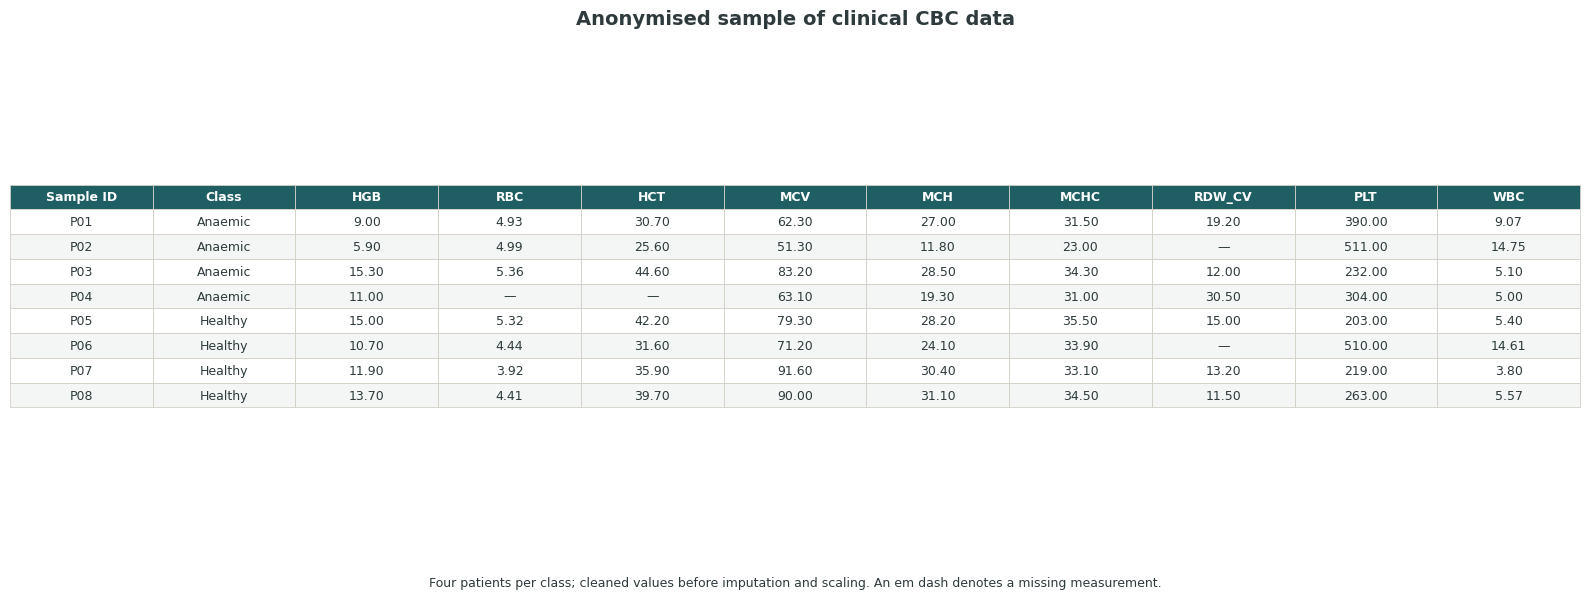

Saved clinical_data_sample.csv and fig_clinical_data_sample.png


In [4]:
# ---- balanced, anonymised clinical sample for the dissertation ----
SAMPLE_PER_CLASS = 4
sample_source = cbc[['patient', 'label'] + FEATURES].copy()
class_counts = sample_source['label'].value_counts()
assert (class_counts >= SAMPLE_PER_CLASS).all(), 'Not enough patients in one class for the sample'

clinical_sample = (sample_source.groupby('label', group_keys=False)
                    .sample(n=SAMPLE_PER_CLASS, random_state=SEED)
                    .sort_values(['label', 'patient'])
                    .reset_index(drop=True))

# Remove source identifiers before display/export. These P-codes are local to this table only.
clinical_sample.insert(0, 'Sample ID', [f'P{i:02d}' for i in range(1, len(clinical_sample) + 1)])
clinical_sample = clinical_sample.drop(columns='patient').rename(columns={'label': 'Class'})
clinical_sample = clinical_sample[['Sample ID', 'Class'] + FEATURES]
clinical_sample[FEATURES] = clinical_sample[FEATURES].round(2)

print(f'Anonymised balanced clinical sample: {len(clinical_sample)} patients '
      f'({SAMPLE_PER_CLASS} per class)')
print(clinical_sample.to_string(index=False, na_rep='—'))
display(clinical_sample.style
        .format({feature: '{:.2f}' for feature in FEATURES}, na_rep='—')
        .set_caption('Anonymised sample of cleaned CBC data (before imputation and scaling)'))

# Machine-readable copy.
clinical_sample.to_csv(OUT/'clinical_data_sample.csv', index=False)

# Dissertation-ready table image.
table_image = clinical_sample.copy()
for feature in FEATURES:
    table_image[feature] = table_image[feature].map(
        lambda value: '—' if pd.isna(value) else f'{value:.2f}')

fig, ax = plt.subplots(figsize=(16, 0.55 * len(table_image) + 2.0))
ax.axis('off')
tbl = ax.table(cellText=table_image.values,
               colLabels=table_image.columns,
               cellLoc='center', colLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.45)

for (row, col), table_cell in tbl.get_celld().items():
    table_cell.set_edgecolor('#D2CFC6')
    table_cell.set_linewidth(0.6)
    if row == 0:
        table_cell.set_facecolor(PALETTE['deep'])
        table_cell.set_text_props(color='white', weight='bold')
    else:
        table_cell.set_facecolor('#F3F6F4' if row % 2 == 0 else 'white')

ax.set_title('Anonymised sample of clinical CBC data', fontsize=14,
             fontweight='bold', pad=14, color=PALETTE['ink'])
fig.text(0.5, 0.035,
         'Four patients per class; cleaned values before imputation and scaling. '
         'An em dash denotes a missing measurement.',
         ha='center', fontsize=9, color=PALETTE['ink'])
plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.savefig(OUT/'fig_clinical_data_sample.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print('Saved clinical_data_sample.csv and fig_clinical_data_sample.png')


In [5]:
# ---- leakage-safe split by patient ----
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=CFG['test_frac'], random_state=SEED)
tr, te = next(gss.split(images, groups=images.patient))
train_all, test_all = images.iloc[tr].reset_index(drop=True), images.iloc[te].reset_index(drop=True)

pool = train_all[train_all.version == CFG['version']].reset_index(drop=True)
test_df = test_all[test_all.version == CFG['version']].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=CFG['val_frac'], random_state=SEED)
t2, v2 = next(gss2.split(pool, groups=pool.patient))
train_df, val_df = pool.iloc[t2].reset_index(drop=True), pool.iloc[v2].reset_index(drop=True)

for a,b in [('train','val'),('train','test'),('val','test')]:
    A = {'train':train_df,'val':val_df,'test':test_df}[a]
    B = {'train':train_df,'val':val_df,'test':test_df}[b]
    assert not (set(A.patient) & set(B.patient)), f'LEAKAGE between {a} and {b}'

print(pd.DataFrame([
 {'split':'train','images':len(train_df),'patients':train_df.patient.nunique()},
 {'split':'val','images':len(val_df),'patients':val_df.patient.nunique()},
 {'split':'test','images':len(test_df),'patients':test_df.patient.nunique()},
]).to_string(index=False))
print('\nPatient overlap between every pair: 0 (asserted)')

train_patients = set(train_df.patient) | set(val_df.patient)
test_patients  = set(test_df.patient)

# ---- exact per-class counts for Table 3.2 (no approximations) ----
split_rows = []
for nm, d in [('Training', train_df), ('Validation', val_df), ('Test', test_df)]:
    pats = d.drop_duplicates('patient')
    split_rows.append({
        'split': nm,
        'patients': d.patient.nunique(),
        'images': len(d),
        'anaemic_patients': int((pats.label == 'Anaemic').sum()),
        'healthy_patients': int((pats.label == 'Healthy').sum()),
        'anaemic_images': int((d.label == 'Anaemic').sum()),
        'healthy_images': int((d.label == 'Healthy').sum()),
    })
split_table = pd.DataFrame(split_rows)
split_table.loc[len(split_table)] = {
    'split': 'Total', 'patients': split_table.patients.sum(), 'images': split_table.images.sum(),
    'anaemic_patients': split_table.anaemic_patients.sum(),
    'healthy_patients': split_table.healthy_patients.sum(),
    'anaemic_images': split_table.anaemic_images.sum(),
    'healthy_images': split_table.healthy_images.sum()}
print()
print('Exact composition of each split (Table 3.2):')
print(split_table.to_string(index=False))
split_table.to_csv(OUT/'split_composition.csv', index=False)


split  images  patients
train    8160       680
  val    1440       120
 test    2400       200

Patient overlap between every pair: 0 (asserted)

Exact composition of each split (Table 3.2):
     split  patients  images  anaemic_patients  healthy_patients  anaemic_images  healthy_images
  Training       680    8160               344               336            4128            4032
Validation       120    1440                59                61             708             732
      Test       200    2400                97               103            1164            1236
     Total      1000   12000               500               500            6000            6000


---
# 3. Exploratory data analysis

Before any model is fitted, three questions are asked of the data: are the classes balanced, do the
images look as expected, and do the clinical indices separate the two groups?

The third question shapes everything that follows. If the CBC indices separate the classes cleanly,
a clinical-only model should perform well and the case for adding images would be weak.

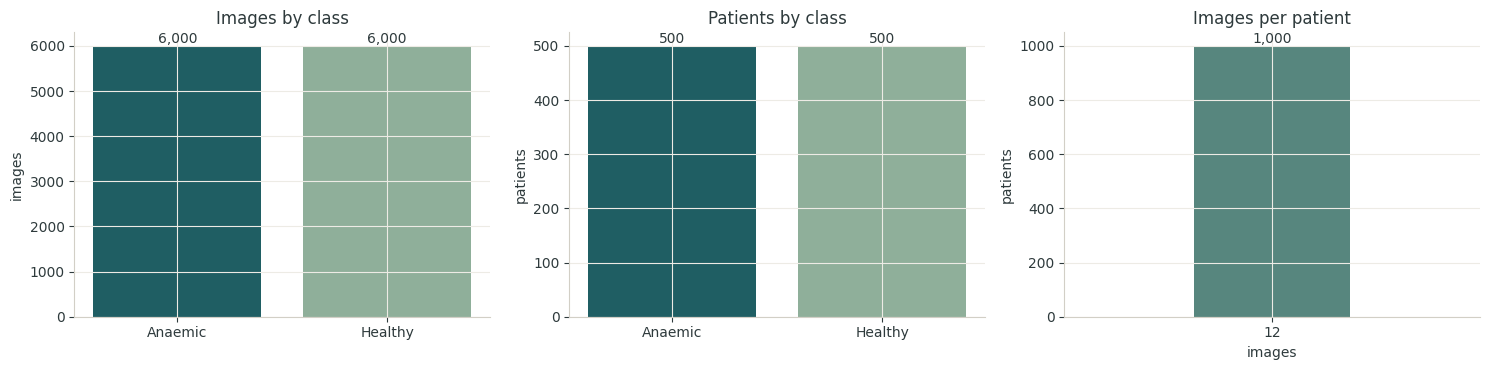

12,000 modelling images from 1,000 patients
                   images
version   label          
AneRBC-II Anaemic    6000
          Healthy    6000


In [6]:
# ---- class balance for the modelling subset, at image and patient level ----
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

c1 = model_images['label'].value_counts()
axes[0].bar(c1.index, c1.values, color=[PALETTE['deep'], PALETTE['sage']])
axes[0].set_title('Images by class'); axes[0].set_ylabel('images')
for i, v in enumerate(c1.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

c2 = model_images.drop_duplicates('patient')['label'].value_counts()
axes[1].bar(c2.index, c2.values, color=[PALETTE['deep'], PALETTE['sage']])
axes[1].set_title('Patients by class'); axes[1].set_ylabel('patients')
for i, v in enumerate(c2.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

per = model_images.groupby('patient').size()
axes[2].bar([12], [len(per)], width=0.45, color=PALETTE['mid'])
axes[2].set_xlim(11.4, 12.6); axes[2].set_xticks([12])
axes[2].set_title('Images per patient'); axes[2].set_xlabel('images'); axes[2].set_ylabel('patients')
axes[2].text(12, len(per), f'{len(per):,}', ha='center', va='bottom')

plt.tight_layout(); plt.savefig(OUT/'fig_class_balance.png', dpi=200, bbox_inches='tight'); plt.show()

print(f"{len(model_images):,} modelling images from {model_images.patient.nunique():,} patients")
print(model_images.groupby(['version','label']).size().to_frame('images'))


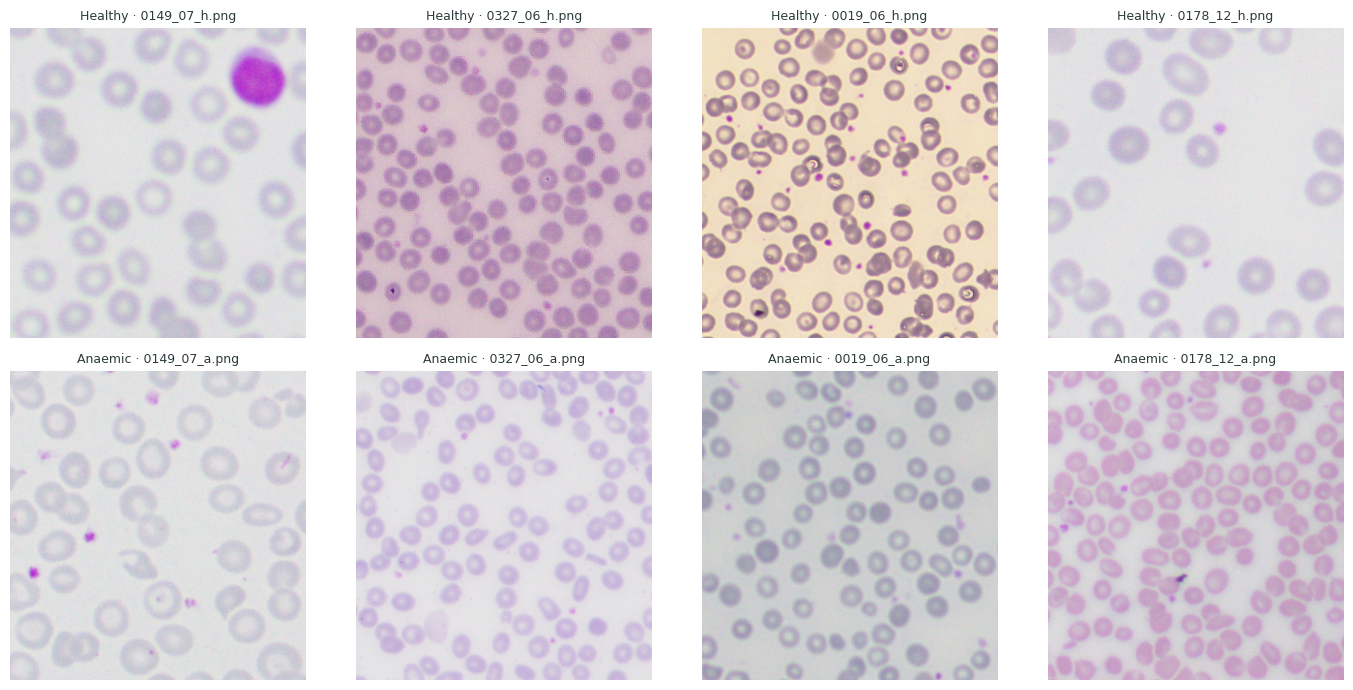

In [7]:
# ---- sample images from each class ----
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for r, lab in enumerate(['Healthy', 'Anaemic']):
    sub = model_images[model_images.label == lab].sample(4, random_state=SEED)
    for c, (_, row) in enumerate(sub.iterrows()):
        axes[r, c].imshow(Image.open(row['path']))
        axes[r, c].axis('off')
        axes[r, c].set_title(f"{lab} \u00b7 {row['file']}", fontsize=9)
plt.tight_layout(); plt.savefig(OUT/'fig_samples.png', dpi=150, bbox_inches='tight'); plt.show()

Cohen's d — 0.2 small, 0.5 medium, 0.8 large
Class-wise SDs are printed so Table 4.1 reconciles with the d column.



,index,anaemic_mean,anaemic_sd,healthy_mean,healthy_sd,pooled_sd,cohens_d,complete_%,missing_%
0,MCH,21.73,5.20,25.11,5.19,5.19,-0.652,99.6,0.4
1,MCV,69.88,11.51,77.29,11.74,11.63,-0.637,98.9,1.1
2,MCHC,30.64,3.01,32.12,2.71,2.87,-0.518,98.1,1.9
3,RDW_CV,17.42,4.96,15.57,4.17,4.55,0.406,64.9,35.1
4,HGB,10.17,2.93,11.26,3.20,3.07,-0.355,98.7,1.3
5,PLT,354.88,183.52,299.24,156.77,170.67,0.326,99.4,0.6
6,HCT,32.84,8.13,35.21,8.67,8.41,-0.283,98.1,1.9
7,RBC,4.73,1.06,4.59,1.08,1.07,0.131,97.5,2.5
8,WBC,9.14,4.23,8.91,4.71,4.47,0.051,99.5,0.5



Table 4.1 (paste these values):
Index        Anaemic mean (SD)     Healthy mean (SD)   Cohen d  Complete %
MCH               21.73 (5.20)          25.11 (5.19)     -0.65        99.6
MCV               69.88 (11.51)          77.29 (11.74)     -0.64        98.9
MCHC              30.64 (3.01)          32.12 (2.71)     -0.52        98.1
RDW_CV            17.42 (4.96)          15.57 (4.17)      0.41        64.9
HGB               10.17 (2.93)          11.26 (3.20)     -0.35        98.7
PLT              354.88 (183.52)         299.24 (156.77)      0.33        99.4
HCT               32.84 (8.13)          35.21 (8.67)     -0.28        98.1
RBC                4.73 (1.06)           4.59 (1.08)      0.13        97.5
WBC                9.14 (4.23)           8.91 (4.71)      0.05        99.5


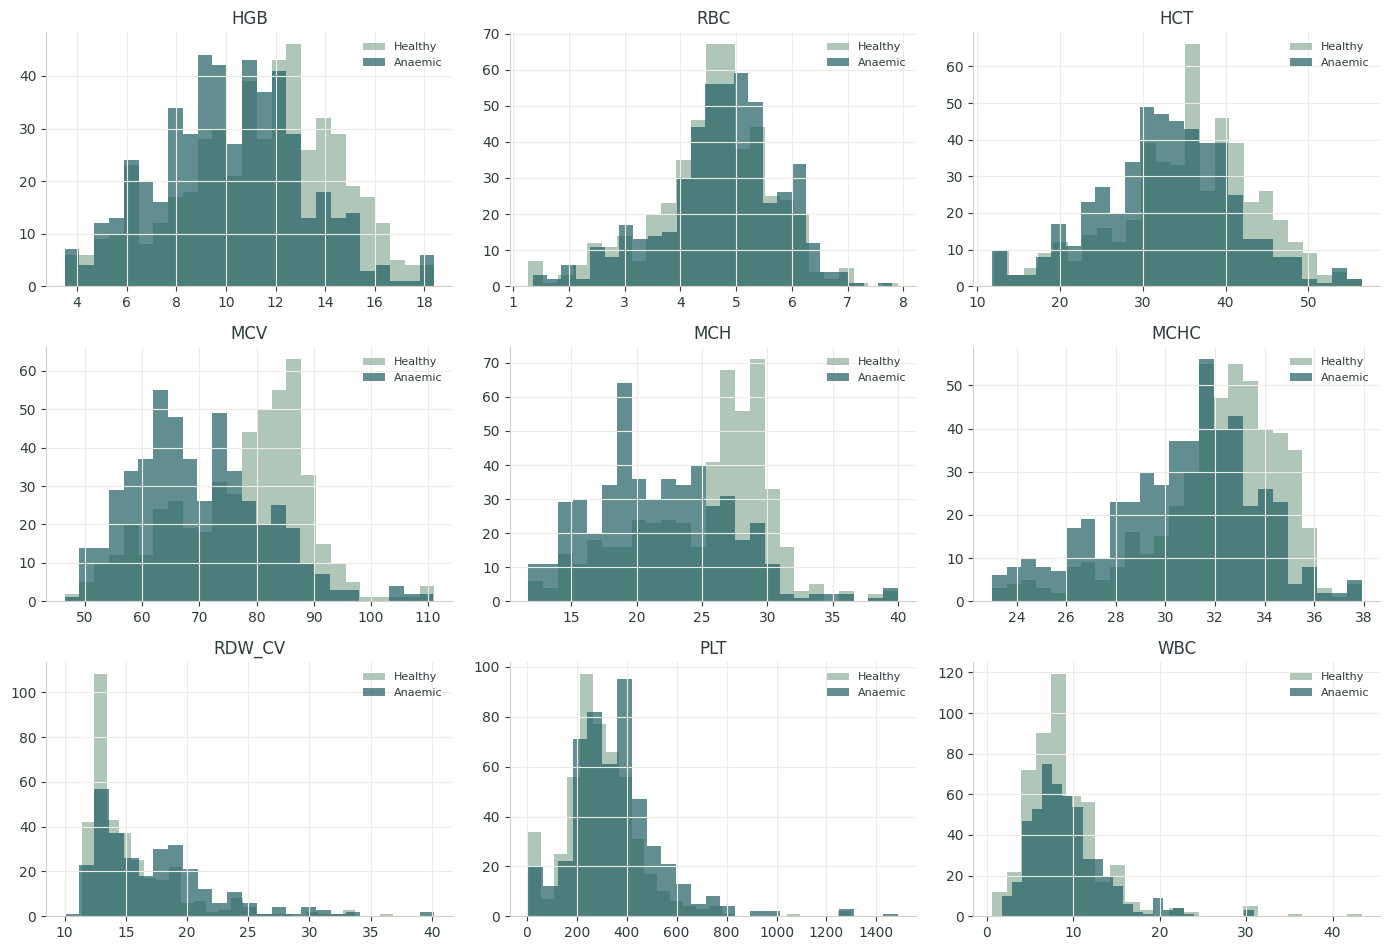

In [8]:
# ---- how well does each clinical index separate the classes? ----
rows = []
for f in FEATURES:
    a = cbc.loc[cbc.label == 'Anaemic', f].dropna()
    h = cbc.loc[cbc.label == 'Healthy', f].dropna()
    pooled = np.sqrt(((len(a)-1)*a.var() + (len(h)-1)*h.var()) / (len(a)+len(h)-2))
    d = (a.mean() - h.mean()) / pooled if pooled else np.nan
    rows.append({'index': f,
                 'anaemic_mean': round(a.mean(),2), 'anaemic_sd': round(a.std(),2),
                 'healthy_mean': round(h.mean(),2), 'healthy_sd': round(h.std(),2),
                 'pooled_sd': round(pooled,2),
                 'cohens_d': round(d,3), 'abs_d': round(abs(d),3),
                 'complete_%': round(cbc[f].notna().mean()*100,1),
                 'missing_%': round(cbc[f].isna().mean()*100,1)})
effects = pd.DataFrame(rows).sort_values('abs_d', ascending=False).reset_index(drop=True)
print("Cohen's d \u2014 0.2 small, 0.5 medium, 0.8 large")
print('Class-wise SDs are printed so Table 4.1 reconciles with the d column.\n')
display(effects.drop(columns='abs_d'))
effects.to_csv(OUT/'cbc_effect_sizes.csv', index=False)

# ---- Table 4.1 exactly as it should appear in the dissertation ----
print('\nTable 4.1 (paste these values):')
print(f"{'Index':<8}{'Anaemic mean (SD)':>22}{'Healthy mean (SD)':>22}{'Cohen d':>10}{'Complete %':>12}")
for _, r in effects.iterrows():
    print(f"{r['index']:<8}"
          f"{r['anaemic_mean']:>15.2f} ({r['anaemic_sd']:.2f})"
          f"{r['healthy_mean']:>15.2f} ({r['healthy_sd']:.2f})"
          f"{r['cohens_d']:>10.2f}{r['complete_%']:>12.1f}")

n = len(FEATURES); ncol = 3; nrow = -(-n // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.2*nrow))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, FEATURES):
    ax.hist(cbc.loc[cbc.label=='Healthy', col].dropna(), bins=25, alpha=0.7,
            label='Healthy', color=PALETTE['sage'])
    ax.hist(cbc.loc[cbc.label=='Anaemic', col].dropna(), bins=25, alpha=0.7,
            label='Anaemic', color=PALETTE['deep'])
    ax.set_title(col); ax.legend(fontsize=8, frameon=False)
for ax in axes[n:]: ax.axis('off')
plt.tight_layout(); plt.savefig(OUT/'fig_cbc_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


**Reading the effect sizes.** Haemoglobin clinically defines anaemia, so it would be
reasonable to expect it to separate the classes strongly. In this dataset it does not: the largest
separations belong to MCH, MCV and MCHC, which describe red-cell size and haemoglobin content
per cell.

This pattern suggests that the benchmark labels are more closely aligned with red-cell morphology
than with a single haemoglobin threshold. It does not establish the label-generation rule by itself;
the source paper describes pathologist interpretation alongside CBC and morphology reports. The
effect sizes therefore motivate, rather than prove, the expectation that the clinical-only arm may
perform more modestly than the image arm.


---
# 4. Extended evaluation metrics

Ten metrics are computed for every model: accuracy, precision, sensitivity, specificity, F1-score,
Matthews correlation coefficient (MCC), Cohen's kappa, ROC-AUC, PR-AUC and Brier score.

| Metric | What it adds |
|---|---|
| **Accuracy** | Overall proportion classified correctly at the 0.5 threshold |
| **Precision** | Proportion of predicted anaemia cases that are truly anaemic |
| **Sensitivity / specificity** | True-positive and true-negative rates; both are needed to describe the operating point |
| **F1-score** | Harmonic mean of precision and sensitivity |
| **MCC** | Correlation-style summary using all four confusion-matrix cells |
| **Cohen's kappa** | Agreement corrected for chance agreement |
| **ROC-AUC** | Ranking performance across all thresholds |
| **PR-AUC** | Precision-recall performance; dependent on the positive-class prevalence |
| **Brier score** | Mean squared probability error; lower is better |

Calibration curves are also plotted, but they are not an additional scalar metric. Because AneRBC
is a deliberately balanced case-control benchmark, precision, PR-AUC, Brier scores and apparent
calibration describe this test set and must not be interpreted as deployment probabilities without
recalibration to the target prevalence.


In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             matthews_corrcoef, cohen_kappa_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

def evaluate(y_true, y_prob, threshold=0.5, name=''):
    """Full metric set for one model's probabilistic predictions."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    return {
        'model'      : name,
        'accuracy'   : accuracy_score(y_true, y_pred),
        'precision'  : precision_score(y_true, y_pred, zero_division=0),
        'sensitivity': recall_score(y_true, y_pred, zero_division=0),      # = recall
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'f1'         : f1_score(y_true, y_pred, zero_division=0),
        'mcc'        : matthews_corrcoef(y_true, y_pred),
        'kappa'      : cohen_kappa_score(y_true, y_pred),
        'roc_auc'    : roc_auc_score(y_true, y_prob),
        'pr_auc'     : average_precision_score(y_true, y_prob),
        'brier'      : brier_score_loss(y_true, y_prob),
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }

def show(res):
    keys = ['accuracy','precision','sensitivity','specificity','f1','mcc','kappa','roc_auc','pr_auc','brier']
    print(f"--- {res['model']} ---")
    print('   ' + '  '.join(f'{k}={res[k]:.3f}' for k in keys))

RESULTS = {}      # model name -> metric dict
PROBS   = {}      # model name -> per-patient probability series (indexed by patient)
print('Metric functions ready.')

Metric functions ready.


---
# 5. Arm 1 - five clinical models

Five classifiers are fitted to the nine CBC indices, chosen to span different assumptions.
Logistic regression assumes linearity; random forest and XGBoost capture non-linear interactions;
an RBF support-vector machine learns a non-linear boundary; and a small MLP tests a neural
approach on tabular data.

Model-family selection uses five-fold stratified cross-validation on the 800 development patients
only. After that choice is fixed, every clinical model is fitted on the development cohort and
reported once on the same 200 held-out test patients used by the image and fusion arms. The test
set is never used to choose the clinical model family.


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost unavailable — skipping that model')

cbc_m = cbc[cbc.patient.isin(train_patients | test_patients)].copy()
X_all = cbc_m[FEATURES]; y_all = (cbc_m.label == 'Anaemic').astype(int)
tr_m = cbc_m.patient.isin(train_patients); te_m = cbc_m.patient.isin(test_patients)
X_tr, y_tr = cbc_m.loc[tr_m, FEATURES], y_all[tr_m]
X_te, y_te = cbc_m.loc[te_m, FEATURES], y_all[te_m]
test_pat_ids = cbc_m.loc[te_m, 'patient'].values

def pipe(clf):
    return Pipeline([('impute', SimpleImputer(strategy='median')),
                     ('scale',  StandardScaler()),
                     ('clf',    clf)])

CLINICAL = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'SVM (RBF)'          : SVC(probability=True, random_state=SEED),
    'MLP'                : MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1500,
                                         random_state=SEED),
}
if HAS_XGB:
    CLINICAL['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                        subsample=0.9, eval_metric='logloss',
                                        random_state=SEED, n_jobs=-1)

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
cv_rows = []
for name, clf in CLINICAL.items():
    r = cross_validate(pipe(clf), X_tr, y_tr, cv=cv,
                       scoring=['accuracy','f1','roc_auc','average_precision'])
    cv_rows.append({'model':name,
                    'cv_accuracy':r['test_accuracy'].mean(), 'cv_acc_sd':r['test_accuracy'].std(),
                    'cv_f1':r['test_f1'].mean(),
                    'cv_roc_auc':r['test_roc_auc'].mean(),
                    'cv_pr_auc':r['test_average_precision'].mean()})
cv_clinical = (pd.DataFrame(cv_rows)
                 .sort_values('cv_roc_auc', ascending=False)
                 .reset_index(drop=True))
print('Five-fold cross-validation on 800 development patients only:')
display(cv_clinical.round(3))

BEST_CLINICAL_NAME = cv_clinical.iloc[0]['model']
BEST_CLINICAL = f'Clinical: {BEST_CLINICAL_NAME}'
print(f'Clinical family selected by development CV ROC-AUC: {BEST_CLINICAL_NAME}')


Five-fold cross-validation on 800 development patients only:


,model,cv_accuracy,cv_acc_sd,cv_f1,cv_roc_auc,cv_pr_auc
0,Logistic Regression,0.649,0.014,0.643,0.677,0.651
1,SVM (RBF),0.654,0.027,0.665,0.675,0.644
2,MLP,0.554,0.045,0.551,0.594,0.580
3,XGBoost,0.529,0.034,0.545,0.561,0.565
4,Random Forest,0.541,0.040,0.556,0.556,0.559


Clinical family selected by development CV ROC-AUC: Logistic Regression


In [11]:
# ---- held-out test evaluation for every clinical model ----
for name, clf in CLINICAL.items():
    model = pipe(clf).fit(X_tr, y_tr)
    prob = model.predict_proba(X_te)[:,1]
    key = f'Clinical: {name}'
    RESULTS[key] = evaluate(y_te, prob, name=key)
    PROBS[key] = pd.Series(prob, index=test_pat_ids)
    show(RESULTS[key])

print(f'\nPre-selected clinical model (development CV): {BEST_CLINICAL}')
print('Held-out test metrics above are final evaluation results, not selection criteria.')

--- Clinical: Logistic Regression ---
   accuracy=0.665  precision=0.653  sensitivity=0.660  specificity=0.670  f1=0.656  mcc=0.330  kappa=0.330  roc_auc=0.715  pr_auc=0.645  brier=0.218
--- Clinical: Random Forest ---
   accuracy=0.565  precision=0.544  sensitivity=0.639  specificity=0.495  f1=0.588  mcc=0.136  kappa=0.134  roc_auc=0.606  pr_auc=0.589  brier=0.283
--- Clinical: SVM (RBF) ---
   accuracy=0.640  precision=0.613  sensitivity=0.701  specificity=0.583  f1=0.654  mcc=0.285  kappa=0.282  roc_auc=0.706  pr_auc=0.676  brier=0.222
--- Clinical: MLP ---
   accuracy=0.550  precision=0.529  sensitivity=0.660  specificity=0.447  f1=0.587  mcc=0.109  kappa=0.106  roc_auc=0.589  pr_auc=0.525  brier=0.309
--- Clinical: XGBoost ---
   accuracy=0.590  precision=0.566  sensitivity=0.660  specificity=0.524  f1=0.610  mcc=0.186  kappa=0.183  roc_auc=0.611  pr_auc=0.575  brier=0.298

Pre-selected clinical model (development CV): Clinical: Logistic Regression
Held-out test metrics above are 

---
# 6. Arm 2 — four image backbones

Four pretrained convolutional architectures are compared, chosen to span different design
philosophies rather than to stack up similar networks.

| Backbone | Idea it introduced | Features |
|---|---|---|
| **ResNet-50** | Residual connections allowing very deep training | 2,048 |
| **EfficientNetB0** | Compound scaling of depth, width and resolution | 1,280 |
| **DenseNet121** | Dense connectivity; every layer feeds all later layers | 1,024 |
| **MobileNetV2** | Depthwise-separable convolutions for efficiency | 1,280 |

MobileNetV2 is included deliberately as the lightweight option. If it performs comparably, that
matters for the clinical motivation of this project, since anaemia screening is most needed in
settings without powerful hardware.

All four use the same two-stage schedule, the same augmentation and the same patient split.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def image_ds(df, training=False):
    paths  = df['path'].values
    labels = (df['label'] == 'Anaemic').astype('float32').values
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [CFG['img_size'], CFG['img_size']])
        img.set_shape([CFG['img_size'], CFG['img_size'], 3])
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(load, num_parallel_calls=AUTOTUNE).batch(CFG['batch_size']).prefetch(AUTOTUNE)

BACKBONES = {
    'EfficientNetB0': (keras.applications.EfficientNetB0, keras.applications.efficientnet.preprocess_input),
    'ResNet50'      : (keras.applications.ResNet50,       keras.applications.resnet50.preprocess_input),
    'DenseNet121'   : (keras.applications.DenseNet121,    keras.applications.densenet.preprocess_input),
    'MobileNetV2'   : (keras.applications.MobileNetV2,    keras.applications.mobilenet_v2.preprocess_input),
}

def augmenter():
    return keras.Sequential([
        layers.RandomFlip('horizontal_and_vertical', seed=SEED),
        layers.RandomRotation(0.15, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ], name='augmentation')

def build_image_model(name):
    ctor, prep = BACKBONES[name]
    base = ctor(include_top=False, weights='imagenet',
                input_shape=(CFG['img_size'], CFG['img_size'], 3))
    base.trainable = False
    inp = keras.Input((CFG['img_size'], CFG['img_size'], 3), name='image')
    x = augmenter()(inp); x = prep(x); x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(CFG['dropout'])(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    return keras.Model(inp, out, name=f'img_{name}'), base, prep

def cbs():
    return [keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                          patience=CFG['patience'], restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                              min_lr=1e-7, verbose=0)]

def two_stage_fit(model, base, tr_ds, va_ds, tag):
    model.compile(optimizer=keras.optimizers.Adam(CFG['head_lr']), loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    t0 = time.time()
    h1 = model.fit(tr_ds, validation_data=va_ds, epochs=CFG['head_epochs'],
                   callbacks=cbs(), verbose=0)
    base.trainable = True
    for l in base.layers[:-CFG['unfreeze']]: l.trainable = False
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization): l.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(CFG['fine_lr']), loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    h2 = model.fit(tr_ds, validation_data=va_ds, epochs=CFG['fine_epochs'],
                   callbacks=cbs(), verbose=0)
    mins = round((time.time()-t0)/60, 1)
    hist = {k: h1.history.get(k,[]) + h2.history.get(k,[]) for k in
            ('accuracy','val_accuracy','loss','val_loss','auc','val_auc')}
    hist['stage1'] = len(h1.history['loss']); hist['minutes'] = mins
    print(f'   {tag}: {mins} min ({hist["stage1"]} + {len(h2.history["loss"])} epochs)')
    return hist

def to_patient(df, probs):
    """Average tile probabilities within each patient."""
    t = df.assign(prob=probs, y=(df.label=='Anaemic').astype(int))
    return t.groupby('patient').agg(prob=('prob','mean'), y=('y','first'))

print('Image pipeline ready.')

Image pipeline ready.


In [13]:
# ---- train all four backbones; select architecture on validation patients only ----
val_ds, test_ds = image_ds(val_df), image_ds(test_df)
image_store, histories, VAL_RESULTS = {}, {}, {}

for name in BACKBONES:
    print(f'\nTraining {name}')
    keras.utils.set_random_seed(SEED)
    # Recreate the shuffled dataset for each model so the fixed seed gives a comparable order.
    train_ds = image_ds(train_df, True)
    model, base, prep = build_image_model(name)
    histories[name] = two_stage_fit(model, base, train_ds, val_ds, name)

    va_prob = model.predict(val_ds, verbose=0).ravel()
    te_prob = model.predict(test_ds, verbose=0).ravel()
    pt_va = to_patient(val_df, va_prob)
    pt_te = to_patient(test_df, te_prob)

    key = f'Image: {name}'
    VAL_RESULTS[key] = evaluate(pt_va['y'], pt_va['prob'], name=key)
    RESULTS[key] = evaluate(pt_te['y'], pt_te['prob'], name=key)
    PROBS[key] = pt_te['prob']
    image_store[name] = {'model':model, 'base':base, 'prep':prep,
                         'test_patient':pt_te, 'val_patient':pt_va}
    print('Validation (selection):')
    show(VAL_RESULTS[key])
    print('Held-out test (evaluation only):')
    show(RESULTS[key])
    model.save(OUT/f'model_{name}.keras')

val_image_table = (pd.DataFrame(VAL_RESULTS.values())
                     [['model','accuracy','sensitivity','specificity','roc_auc','pr_auc']]
                     .sort_values('roc_auc', ascending=False).reset_index(drop=True))
print('\nImage-backbone validation ranking:')
display(val_image_table.round(3))

BEST_IMAGE = max(VAL_RESULTS, key=lambda k: VAL_RESULTS[k]['roc_auc'])
BEST_BACKBONE = BEST_IMAGE.split(': ')[1]
print(f'Backbone selected by patient-level validation ROC-AUC: {BEST_BACKBONE}')
print('The held-out test set was not used for this choice.')



Training EfficientNetB0


I0000 00:00:1787785327.157669      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


E0000 00:00:1787785343.704877      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/img_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1787785614.303135      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/img_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


   EfficientNetB0: 9.2 min (15 + 15 epochs)
Validation (selection):
--- Image: EfficientNetB0 ---
   accuracy=0.833  precision=0.898  sensitivity=0.746  specificity=0.918  f1=0.815  mcc=0.675  kappa=0.666  roc_auc=0.908  pr_auc=0.927  brier=0.119
Held-out test (evaluation only):
--- Image: EfficientNetB0 ---
   accuracy=0.835  precision=0.864  sensitivity=0.784  specificity=0.883  f1=0.822  mcc=0.672  kappa=0.669  roc_auc=0.938  pr_auc=0.944  brier=0.101

Training ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   ResNet50: 10.5 min (15 + 8 epochs)
Validation (selection):
--- Image: ResNet50 ---
   accuracy=0.858  precision=0.809  sensitivity=0.932  specificity=0.787  f1=0.866  mcc=0.725  kappa=0.717  roc_auc=0.946  pr_auc=0.954  brier=0.109
Held-out test (evaluation only):
--- Image: ResNet50 ---
   accuracy=0.790  precision=0.748  sensitivity=0.856  specificity=0.728  f1=0.798  mcc=0.587  kappa=0.581  roc_auc=0.927  pr_auc=0.934  brier=0.116

Training DenseNet121
29084464

,model,accuracy,sensitivity,specificity,roc_auc,pr_auc
0,Image: ResNet50,0.858,0.932,0.787,0.946,0.954
1,Image: MobileNetV2,0.817,0.712,0.918,0.944,0.941
2,Image: EfficientNetB0,0.833,0.746,0.918,0.908,0.927
3,Image: DenseNet121,0.792,0.864,0.721,0.888,0.900


Backbone selected by patient-level validation ROC-AUC: ResNet50
The held-out test set was not used for this choice.


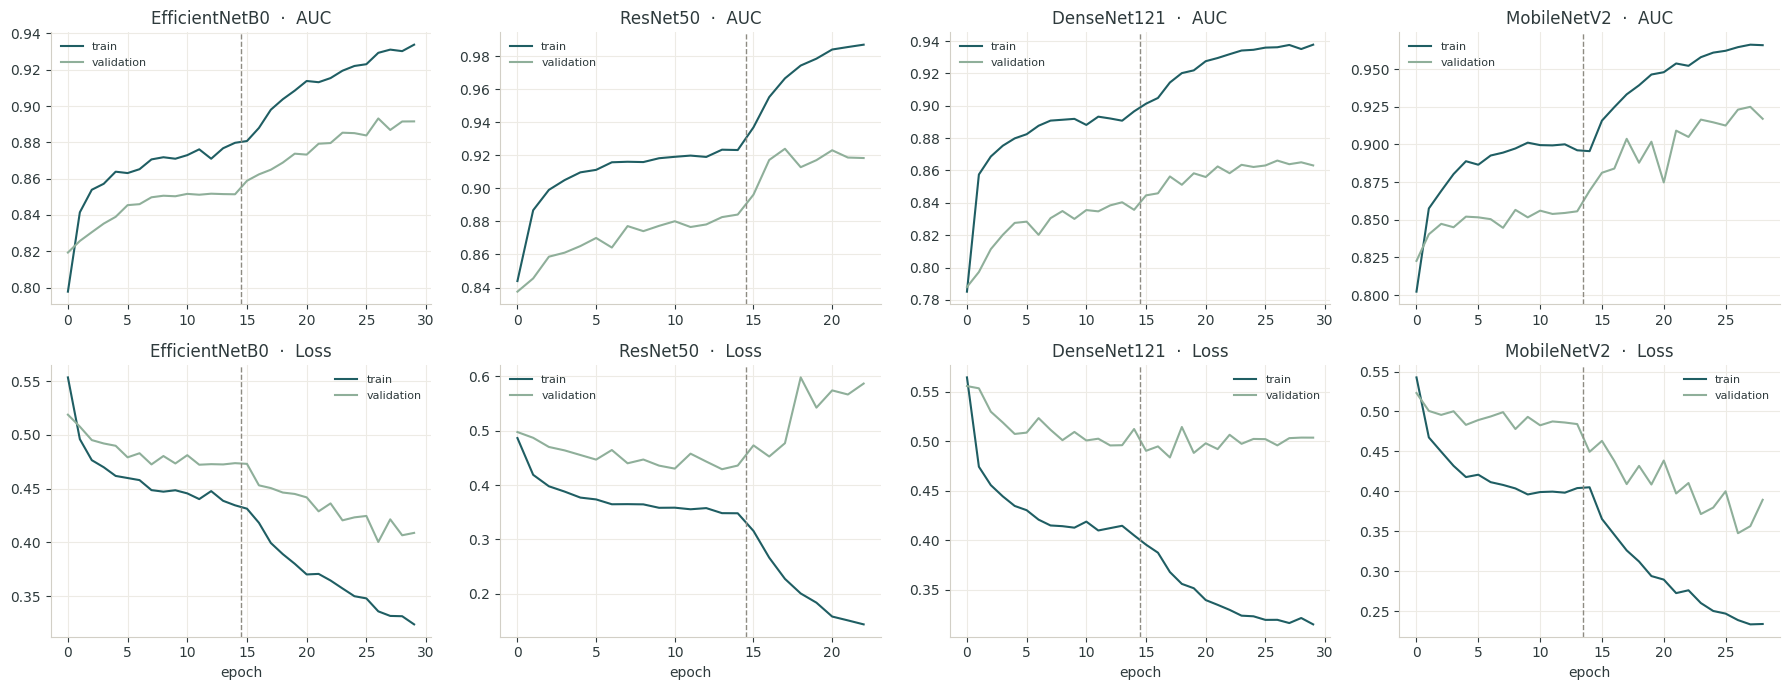

In [14]:
# ---- training curves for all four ----
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for j, name in enumerate(BACKBONES):
    h = histories[name]
    axes[0,j].plot(h['auc'], label='train', color=PALETTE['deep'])
    axes[0,j].plot(h['val_auc'], label='validation', color=PALETTE['sage'])
    axes[0,j].axvline(h['stage1']-0.5, color=PALETTE['grey'], ls='--', lw=1)
    axes[0,j].set_title(f'{name}  ·  AUC'); axes[0,j].legend(fontsize=8, frameon=False)
    axes[1,j].plot(h['loss'], label='train', color=PALETTE['deep'])
    axes[1,j].plot(h['val_loss'], label='validation', color=PALETTE['sage'])
    axes[1,j].axvline(h['stage1']-0.5, color=PALETTE['grey'], ls='--', lw=1)
    axes[1,j].set_title(f'{name}  ·  Loss'); axes[1,j].set_xlabel('epoch')
    axes[1,j].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(OUT/'fig_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

---
# 7. Arm 3 - two fusion strategies

The image architecture entering both fusion models is selected by patient-level validation
ROC-AUC, not by test performance.

**Feature-level fusion** encodes the image and CBC vector separately, concatenates their learned
representations, and trains one classifier end to end.

**Late fusion** combines the selected image probability with the clinical probability using a
logistic-regression stacker fitted on validation patients. The test set remains untouched. The same
validation cohort also informed early stopping of the image model, so this is a pragmatic hold-out
stacking design rather than fully nested or out-of-fold stacking; that limitation should be stated.


In [15]:
# ---- feature-level fusion ----
cbc_feat = cbc[['patient'] + FEATURES]
train_f = train_df.merge(cbc_feat, on='patient', how='left')
val_f   = val_df.merge(cbc_feat,  on='patient', how='left')
test_f  = test_df.merge(cbc_feat, on='patient', how='left')

tab_imp = SimpleImputer(strategy='median').fit(train_f[FEATURES])
tab_sc  = StandardScaler().fit(tab_imp.transform(train_f[FEATURES]))
def tab(df): return tab_sc.transform(tab_imp.transform(df[FEATURES])).astype('float32')
TAB_TR, TAB_VA, TAB_TE = tab(train_f), tab(val_f), tab(test_f)

def fusion_ds(df, tabm, training=False):
    paths  = df['path'].values
    labels = (df['label']=='Anaemic').astype('float32').values
    def load(path, t, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [CFG['img_size'], CFG['img_size']])
        img.set_shape([CFG['img_size'], CFG['img_size'], 3])
        return (img, t), label
    ds = tf.data.Dataset.from_tensor_slices((paths, tabm, labels))
    if training: ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(load, num_parallel_calls=AUTOTUNE).batch(CFG['batch_size']).prefetch(AUTOTUNE)

def build_fusion(name, n_tab):
    ctor, prep = BACKBONES[name]
    base = ctor(include_top=False, weights='imagenet',
                input_shape=(CFG['img_size'], CFG['img_size'], 3))
    base.trainable = False
    img_in = keras.Input((CFG['img_size'], CFG['img_size'], 3), name='image')
    x = augmenter()(img_in); x = prep(x); x = base(x, training=False)
    img_feat = layers.GlobalAveragePooling2D(name='image_features')(x)
    tab_in = keras.Input((n_tab,), name='clinical')
    t = tab_in
    for i, u in enumerate(CFG['mlp_units']):
        t = layers.Dense(u, activation='relu', name=f'mlp_{i+1}')(t)
        t = layers.BatchNormalization()(t); t = layers.Dropout(0.2)(t)
    z = layers.Concatenate(name='fusion')([img_feat, t])
    z = layers.Dropout(CFG['dropout'])(z)
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(CFG['dropout'])(z)
    out = layers.Dense(1, activation='sigmoid', name='output')(z)
    return keras.Model([img_in, tab_in], out, name=f'fusion_{name}'), base

print(f'Feature-level fusion on {BEST_BACKBONE}')
keras.utils.set_random_seed(SEED)
fmodel, fbase = build_fusion(BEST_BACKBONE, len(FEATURES))
hist_fusion = two_stage_fit(fmodel, fbase,
                            fusion_ds(train_f, TAB_TR, True),
                            fusion_ds(val_f, TAB_VA), 'Feature-level fusion')

f_te = fmodel.predict(fusion_ds(test_f, TAB_TE), verbose=0).ravel()
pt_fuse = to_patient(test_f, f_te)
RESULTS['Fusion: feature-level'] = evaluate(pt_fuse['y'], pt_fuse['prob'],
                                            name='Fusion: feature-level')
PROBS['Fusion: feature-level'] = pt_fuse['prob']
show(RESULTS['Fusion: feature-level'])
fmodel.save(OUT/'model_fusion_featurelevel.keras')

Feature-level fusion on ResNet50
   Feature-level fusion: 10.0 min (15 + 6 epochs)
--- Fusion: feature-level ---
   accuracy=0.890  precision=0.844  sensitivity=0.948  specificity=0.835  f1=0.893  mcc=0.786  kappa=0.781  roc_auc=0.957  pr_auc=0.952  brier=0.082


### 7a. Control: does the gain come from the clinical modality or from the architecture?

Comparing feature-level fusion against the image-only ResNet-50 changes three things at once.
It adds the clinical branch, it trains a fresh ResNet-50 from ImageNet weights as a separate
run, and it adds a `Dense(64)` layer plus an extra dropout stage to the head. The observed
ROC-AUC gain is therefore not attributable to the modality alone.

The control below rebuilds the **identical** fusion architecture and trains it with the same
seed and the same schedule, but each patient receives another patient's clinical vector. The
branch still sees nine plausible blood indices with the correct marginal distribution; what it
no longer sees is any association between those indices and the label.

- If the shuffled model falls back towards the image-only result, the clinical modality caused
  the gain and the fusion claim is supported by a clean ablation.
- If the shuffled model holds near the real fusion result, the gain came from the extra head
  capacity and the second training run, and the claim must be restated.

Report whichever outcome occurs.

In [16]:
# ---- CONTROL: feature-level fusion with clinical vectors shuffled across patients ----
CONTROL, CONTROL_PROBS = {}, {}

def shuffle_clinical(df, tabm, rng):
    """Give every patient another patient's clinical vector.

    Shuffling happens at PATIENT level, not row level, so all twelve tiles of a patient keep a
    single consistent (but wrong) clinical vector. The marginal distribution of the nine indices
    is unchanged; only the association with the label is destroyed.
    """
    s = pd.DataFrame(tabm, index=df['patient'].values)
    lut = s.groupby(level=0).first()
    perm = rng.permutation(len(lut))
    lut_shuffled = pd.DataFrame(lut.to_numpy()[perm], index=lut.index)
    return lut_shuffled.loc[df['patient'].values].to_numpy().astype('float32')

rng = np.random.default_rng(SEED)
TAB_TR_S = shuffle_clinical(train_f, TAB_TR, rng)
TAB_VA_S = shuffle_clinical(val_f,   TAB_VA, rng)
TAB_TE_S = shuffle_clinical(test_f,  TAB_TE, rng)

# sanity: the shuffle must move most patients, and must stay constant within a patient
_chk = pd.DataFrame(TAB_TR_S, index=train_f['patient'].values)
assert _chk.groupby(level=0).nunique().max().max() == 1, 'clinical vector varies within a patient'
moved = 1.0 - np.mean(np.all(np.isclose(TAB_TR_S, TAB_TR), axis=1))
print(f'Shuffled clinical vectors: {moved*100:.1f}% of image rows now carry another patient\'s CBC')

keras.utils.set_random_seed(SEED)
smodel, sbase = build_fusion(BEST_BACKBONE, len(FEATURES))
hist_shuffled = two_stage_fit(smodel, sbase,
                              fusion_ds(train_f, TAB_TR_S, True),
                              fusion_ds(val_f, TAB_VA_S), 'Fusion control (clinical shuffled)')

s_te = smodel.predict(fusion_ds(test_f, TAB_TE_S), verbose=0).ravel()
pt_shuf = to_patient(test_f, s_te)
CONTROL['Control: fusion, clinical shuffled'] = evaluate(
    pt_shuf['y'], pt_shuf['prob'], name='Control: fusion, clinical shuffled')
CONTROL_PROBS['Control: fusion, clinical shuffled'] = pt_shuf['prob']
show(CONTROL['Control: fusion, clinical shuffled'])

# ---- the three-way comparison the dissertation needs ----
ctrl = CONTROL['Control: fusion, clinical shuffled']
real = RESULTS['Fusion: feature-level']
img  = RESULTS[BEST_IMAGE]

comparison = pd.DataFrame([
    {'model': f'{BEST_BACKBONE} (image only)',        **{k: img[k]  for k in
        ['accuracy','sensitivity','specificity','roc_auc','brier']}, 'missed_anaemic': img['fn']},
    {'model': 'Fusion, clinical SHUFFLED (control)',  **{k: ctrl[k] for k in
        ['accuracy','sensitivity','specificity','roc_auc','brier']}, 'missed_anaemic': ctrl['fn']},
    {'model': 'Fusion, clinical REAL',                **{k: real[k] for k in
        ['accuracy','sensitivity','specificity','roc_auc','brier']}, 'missed_anaemic': real['fn']},
]).round(3)
print('\nAblation: what the clinical modality is actually worth')
display(comparison)
comparison.to_csv(OUT/'ablation_clinical_branch.csv', index=False)

arch_effect = ctrl['roc_auc'] - img['roc_auc']
modality_effect = real['roc_auc'] - ctrl['roc_auc']
total_effect = real['roc_auc'] - img['roc_auc']
print(f'\nTotal gain over image-only ROC-AUC      : {total_effect:+.3f}')
print(f'  attributable to architecture + re-run : {arch_effect:+.3f}')
print(f'  attributable to the clinical modality : {modality_effect:+.3f}')

# paired test: real fusion against its own shuffled control, same patients, same architecture
from scipy.stats import binomtest as _binomtest

_labels = (test_df.drop_duplicates('patient').set_index('patient')['label'] == 'Anaemic').astype(int)
_common = sorted(set(PROBS['Fusion: feature-level'].index) &
                 set(CONTROL_PROBS['Control: fusion, clinical shuffled'].index))
_y  = _labels.loc[_common].to_numpy()
_pr = (PROBS['Fusion: feature-level'].loc[_common].values >= 0.5).astype(int)
_pc = (CONTROL_PROBS['Control: fusion, clinical shuffled'].loc[_common].values >= 0.5).astype(int)
_a = int(np.sum((_pr == _y) & (_pc != _y)))      # real correct, control wrong
_b = int(np.sum((_pr != _y) & (_pc == _y)))      # control correct, real wrong
_n = _a + _b
_p = 1.0 if _n == 0 else float(_binomtest(_a, _n, 0.5).pvalue)

print(f'\nExact McNemar over {len(_common)} patients, real against shuffled clinical branch:')
print(f'  real fusion only correct   : {_a}')
print(f'  shuffled control only right: {_b}')
print(f'  exact two-sided p          : {_p:.4g}')
print('  Reported separately from the six pre-specified headline comparisons, so it does')
print('  not enter the Holm family. State that in the write-up.')

pd.DataFrame([{'comparison': 'feature fusion vs shuffled-clinical control',
               'patients': len(_common), 'real_only_correct': _a,
               'control_only_correct': _b, 'exact_p': _p,
               'image_only_auc': img['roc_auc'], 'control_auc': ctrl['roc_auc'],
               'real_auc': real['roc_auc'],
               'architecture_effect': round(arch_effect, 3),
               'modality_effect': round(modality_effect, 3)}]
            ).to_csv(OUT/'ablation_mcnemar.csv', index=False)

print('\nWrite up whichever outcome occurred. A control that removes the effect is a result;')
print('a control that does not remove it is a more interesting result.')


Shuffled clinical vectors: 99.3% of image rows now carry another patient's CBC
   Fusion control (clinical shuffled): 11.4 min (8 + 14 epochs)
--- Control: fusion, clinical shuffled ---
   accuracy=0.850  precision=0.860  sensitivity=0.825  specificity=0.874  f1=0.842  mcc=0.700  kappa=0.699  roc_auc=0.945  pr_auc=0.948  brier=0.096

Ablation: what the clinical modality is actually worth


,model,accuracy,sensitivity,specificity,roc_auc,brier,missed_anaemic
0,ResNet50 (image only),0.79,0.856,0.728,0.927,0.116,14
1,"Fusion, clinical SHUFFLED (control)",0.85,0.825,0.874,0.945,0.096,17
2,"Fusion, clinical REAL",0.89,0.948,0.835,0.957,0.082,5



Total gain over image-only ROC-AUC      : +0.029
  attributable to architecture + re-run : +0.017
  attributable to the clinical modality : +0.012

Exact McNemar over 200 patients, real against shuffled clinical branch:
  real fusion only correct   : 18
  shuffled control only right: 10
  exact two-sided p          : 0.1849
  Reported separately from the six pre-specified headline comparisons, so it does
  not enter the Holm family. State that in the write-up.

Write up whichever outcome occurred. A control that removes the effect is a result;
a control that does not remove it is a more interesting result.


### 7b. Optional: seed stability

Every headline figure so far rests on one training run per model. McNemar accounts for which
patients landed in the test set, but not for run-to-run variance in fine-tuning. The gap is
worth checking: the selected ResNet-50 scored 0.946 on validation and 0.927 on test in v05, a
swing of 0.019, which is comparable in size to the fusion gain being claimed.

This cell retrains the image-only backbone and the fusion model under three seeds each and
reports the mean and range. It costs roughly an hour on a P100. Set `RUN_MULTISEED = False` to
skip it; the rest of the notebook does not depend on it.

In [17]:
# ---- optional: seed stability for the two models the headline claim rests on ----
RUN_MULTISEED = True        # set False to skip (saves ~1 hour of GPU time)
SEEDS = [42, 1337, 2024]

seed_rows = []
if RUN_MULTISEED:
    for s in SEEDS:
        try:
            # image-only backbone
            keras.utils.set_random_seed(s)
            m_i, b_i, _ = build_image_model(BEST_BACKBONE)
            two_stage_fit(m_i, b_i, image_ds(train_df, True), val_ds, f'{BEST_BACKBONE} seed {s}')
            p_i = to_patient(test_df, m_i.predict(test_ds, verbose=0).ravel())
            r_i = evaluate(p_i['y'], p_i['prob'], name=f'{BEST_BACKBONE} seed {s}')
            seed_rows.append({'model': f'{BEST_BACKBONE} (image only)', 'seed': s,
                              'roc_auc': r_i['roc_auc'], 'accuracy': r_i['accuracy'],
                              'sensitivity': r_i['sensitivity'], 'missed_anaemic': r_i['fn']})
            del m_i, b_i
            keras.backend.clear_session()

            # feature-level fusion
            keras.utils.set_random_seed(s)
            m_f, b_f = build_fusion(BEST_BACKBONE, len(FEATURES))
            two_stage_fit(m_f, b_f, fusion_ds(train_f, TAB_TR, True),
                          fusion_ds(val_f, TAB_VA), f'fusion seed {s}')
            p_f = to_patient(test_f, m_f.predict(fusion_ds(test_f, TAB_TE), verbose=0).ravel())
            r_f = evaluate(p_f['y'], p_f['prob'], name=f'fusion seed {s}')
            seed_rows.append({'model': 'Fusion: feature-level', 'seed': s,
                              'roc_auc': r_f['roc_auc'], 'accuracy': r_f['accuracy'],
                              'sensitivity': r_f['sensitivity'], 'missed_anaemic': r_f['fn']})
            del m_f, b_f
            keras.backend.clear_session()
        except Exception as e:
            print(f'  seed {s} failed: {type(e).__name__}: {e}')

if seed_rows:
    seeds_df = pd.DataFrame(seed_rows)
    display(seeds_df.round(3))
    summary_seeds = (seeds_df.groupby('model')
                     .agg(auc_mean=('roc_auc','mean'), auc_min=('roc_auc','min'),
                          auc_max=('roc_auc','max'), missed_mean=('missed_anaemic','mean'),
                          missed_min=('missed_anaemic','min'), missed_max=('missed_anaemic','max'),
                          n_seeds=('seed','count'))
                     .round(3))
    print('\nSeed stability (report mean and range, not a single run):')
    display(summary_seeds)
    seeds_df.to_csv(OUT/'seed_stability.csv', index=False)
    print('\nIf the two ranges overlap, say so plainly and soften the fusion claim accordingly.')
else:
    print('Multi-seed run skipped. The dissertation must then state that every figure')
    print('comes from a single training run with seed 42.')

   ResNet50 seed 42: 10.5 min (15 + 8 epochs)
   fusion seed 42: 9.9 min (15 + 6 epochs)
   ResNet50 seed 1337: 12.5 min (10 + 15 epochs)
   fusion seed 1337: 8.2 min (11 + 6 epochs)
   ResNet50 seed 2024: 12.5 min (11 + 15 epochs)
   fusion seed 2024: 10.2 min (12 + 9 epochs)


,model,seed,roc_auc,accuracy,sensitivity,missed_anaemic
0,ResNet50 (image only),42,0.924,0.795,0.866,13
1,Fusion: feature-level,42,0.958,0.900,0.948,5
2,ResNet50 (image only),1337,0.948,0.870,0.928,7
3,Fusion: feature-level,1337,0.957,0.895,0.948,5
4,ResNet50 (image only),2024,0.949,0.870,0.918,8
5,Fusion: feature-level,2024,0.962,0.900,0.948,5



Seed stability (report mean and range, not a single run):


,auc_mean,auc_min,auc_max,missed_mean,missed_min,missed_max,n_seeds
model,,,,,,,
Fusion: feature-level,0.959,0.957,0.962,5.000,5,5,3
ResNet50 (image only),0.941,0.924,0.949,9.333,7,13,3



If the two ranges overlap, say so plainly and soften the fusion claim accordingly.


In [18]:
# ---- late fusion (stacked) ----
# combiner is fitted on VALIDATION patients only, then applied once to the test set
best_clin_name = BEST_CLINICAL_NAME

# The clinical base model is trained without validation patients before producing stacking
# features. The image model did use validation for early stopping, so the design is not fully
# nested; it still keeps the held-out test set out of all fitting and selection.
train_only = set(train_df.patient)
tr_only_mask = cbc_m.patient.isin(train_only)
clin_model = pipe(CLINICAL[best_clin_name]).fit(cbc_m.loc[tr_only_mask, FEATURES],
                                                y_all[tr_only_mask])
print(f'Late-fusion clinical model fitted on {int(tr_only_mask.sum())} training-only patients')

val_pats = cbc_m[cbc_m.patient.isin(set(val_df.patient))].copy()
test_pats = cbc_m[cbc_m.patient.isin(test_patients)].copy()
clin_val = pd.Series(clin_model.predict_proba(val_pats[FEATURES])[:,1],
                     index=val_pats.patient.values)
clin_test = pd.Series(clin_model.predict_proba(test_pats[FEATURES])[:,1],
                      index=test_pats.patient.values)

img_val  = image_store[BEST_BACKBONE]['val_patient']['prob']
img_test = image_store[BEST_BACKBONE]['test_patient']['prob']

va = pd.DataFrame({'img': img_val, 'clin': clin_val}).dropna()
te = pd.DataFrame({'img': img_test, 'clin': clin_test}).dropna()
label_lookup = (cbc_m.drop_duplicates('patient').set_index('patient')['label'] == 'Anaemic').astype(int)
va['y'] = label_lookup.reindex(va.index).astype(int)
te['y'] = label_lookup.reindex(te.index).astype(int)

print(f'Late-fusion combiner fitted on {len(va)} validation patients, '
      f'applied to {len(te)} test patients')

combiner = LogisticRegression(max_iter=1000, random_state=SEED).fit(va[['img','clin']], va['y'])
late_prob = combiner.predict_proba(te[['img','clin']])[:,1]

RESULTS['Fusion: late (stacked)'] = evaluate(te['y'], late_prob, name='Fusion: late (stacked)')
PROBS['Fusion: late (stacked)'] = pd.Series(late_prob, index=te.index)
show(RESULTS['Fusion: late (stacked)'])
print(f'\nCombiner weights — image: {combiner.coef_[0][0]:.3f}, '
      f'clinical: {combiner.coef_[0][1]:.3f}')

Late-fusion clinical model fitted on 680 training-only patients
Late-fusion combiner fitted on 120 validation patients, applied to 200 test patients
--- Fusion: late (stacked) ---
   accuracy=0.830  precision=0.839  sensitivity=0.804  specificity=0.854  f1=0.821  mcc=0.660  kappa=0.659  roc_auc=0.935  pr_auc=0.942  brier=0.107

Combiner weights — image: 4.046, clinical: 1.456


---
# 8. Comparative evaluation

All eleven models are evaluated on the same 200 held-out patients using the same ten metrics.
The ordering below is a descriptive test-set comparison after the clinical family and image
backbone have already been selected on development/validation data.


In [19]:
table = pd.DataFrame(RESULTS.values())
cols = ['model','accuracy','sensitivity','specificity','precision','f1',
        'mcc','kappa','roc_auc','pr_auc','brier']
table = table[cols + ['tp','tn','fp','fn']].sort_values('roc_auc', ascending=False)
table_r = table.round(3).reset_index(drop=True)
print(f'{len(table)} models, ranked by ROC-AUC:')
display(table_r)
table_r.to_csv(OUT/'results_all_models_extended.csv', index=False)

TOP_TEST_MODEL = table.iloc[0]['model']
print(f'\nTop-scoring model on the held-out test set (descriptive): {TOP_TEST_MODEL}')

11 models, ranked by ROC-AUC:


,model,accuracy,sensitivity,specificity,precision,f1,mcc,kappa,roc_auc,pr_auc,brier,tp,tn,fp,fn
0,Fusion: feature-level,0.890,0.948,0.835,0.844,0.893,0.786,0.781,0.957,0.952,0.082,92,86,17,5
1,Image: EfficientNetB0,0.835,0.784,0.883,0.864,0.822,0.672,0.669,0.938,0.944,0.101,76,91,12,21
2,Fusion: late (stacked),0.830,0.804,0.854,0.839,0.821,0.660,0.659,0.935,0.942,0.107,78,88,15,19
3,Image: MobileNetV2,0.855,0.784,0.922,0.905,0.840,0.715,0.709,0.935,0.941,0.102,76,95,8,21
4,Image: DenseNet121,0.825,0.918,0.738,0.767,0.836,0.664,0.652,0.932,0.935,0.116,89,76,27,8
5,Image: ResNet50,0.790,0.856,0.728,0.748,0.798,0.587,0.581,0.927,0.934,0.116,83,75,28,14
6,Clinical: Logistic Regression,0.665,0.660,0.670,0.653,0.656,0.330,0.330,0.715,0.645,0.218,64,69,34,33
7,Clinical: SVM (RBF),0.640,0.701,0.583,0.613,0.654,0.285,0.282,0.706,0.676,0.222,68,60,43,29
8,Clinical: XGBoost,0.590,0.660,0.524,0.566,0.610,0.186,0.183,0.611,0.575,0.298,64,54,49,33
9,Clinical: Random Forest,0.565,0.639,0.495,0.544,0.588,0.136,0.134,0.606,0.589,0.283,62,51,52,35



Top-scoring model on the held-out test set (descriptive): Fusion: feature-level


In [20]:
# ---- explicit feature-level versus late-fusion trade-off ----
fusion_pair = (table.set_index('model')
               .loc[['Fusion: feature-level', 'Fusion: late (stacked)'],
                    ['accuracy','precision','sensitivity','specificity','f1','mcc','kappa',
                     'roc_auc','pr_auc','brier']])
display(fusion_pair.round(3))

higher_better = ['accuracy','precision','sensitivity','specificity','f1','mcc','kappa',
                 'roc_auc','pr_auc']
feature_wins = [m for m in higher_better
                if fusion_pair.loc['Fusion: feature-level', m] >
                   fusion_pair.loc['Fusion: late (stacked)', m]]
late_wins = [m for m in higher_better
             if fusion_pair.loc['Fusion: late (stacked)', m] >
                fusion_pair.loc['Fusion: feature-level', m]]
if fusion_pair.loc['Fusion: feature-level','brier'] < fusion_pair.loc['Fusion: late (stacked)','brier']:
    feature_wins.append('brier (lower)')
else:
    late_wins.append('brier (lower)')
print('Feature-level leads:', ', '.join(feature_wins))
print('Late fusion leads   :', ', '.join(late_wins))
print('Use this trade-off in the report; never replace it with "best on every metric".')


,accuracy,precision,sensitivity,specificity,f1,mcc,kappa,roc_auc,pr_auc,brier
model,,,,,,,,,,
Fusion: feature-level,0.89,0.844,0.948,0.835,0.893,0.786,0.781,0.957,0.952,0.082
Fusion: late (stacked),0.83,0.839,0.804,0.854,0.821,0.660,0.659,0.935,0.942,0.107


Feature-level leads: accuracy, precision, sensitivity, f1, mcc, kappa, roc_auc, pr_auc, brier (lower)
Late fusion leads   : specificity
Use this trade-off in the report; never replace it with "best on every metric".


### Confusion matrices

The metric table above summarises performance; the matrices below show where each model's errors
actually fall. False negatives sit in the lower-left cell, and in a diagnostic setting those are
the costly errors.

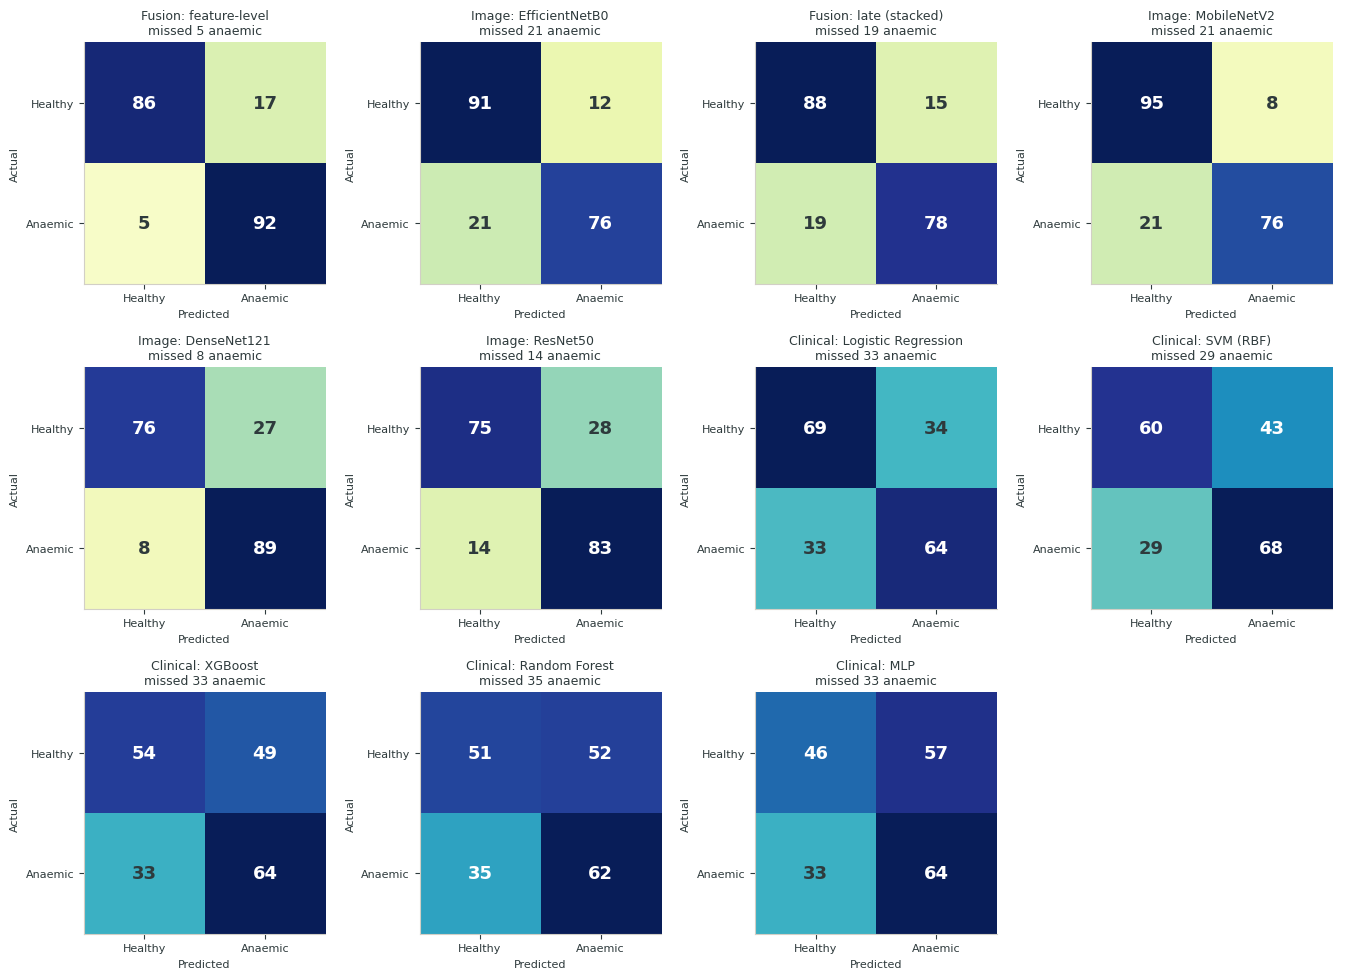

Ranked by missed anaemia cases (the clinically costly error):


,model,missed_anaemic,false_alarms,sensitivity
0,Fusion: feature-level,5,17,0.948
1,Image: DenseNet121,8,27,0.918
2,Image: ResNet50,14,28,0.856
3,Fusion: late (stacked),19,15,0.804
4,Image: EfficientNetB0,21,12,0.784
5,Image: MobileNetV2,21,8,0.784
6,Clinical: SVM (RBF),29,43,0.701
7,Clinical: Logistic Regression,33,34,0.660
8,Clinical: MLP,33,57,0.660
9,Clinical: XGBoost,33,49,0.660


In [21]:
# ---- confusion matrix for every model ----
from sklearn.metrics import confusion_matrix

order = table['model'].tolist()
ncol = 4; nrow = -(-len(order) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4*ncol, 3.3*nrow))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, order):
    r = RESULTS[name]
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    ax.imshow(cm, cmap='YlGnBu', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.55 else PALETTE['ink'])
    ax.set_xticks([0,1]); ax.set_xticklabels(['Healthy','Anaemic'], fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Healthy','Anaemic'], fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
    ax.set_title(f"{name}\nmissed {r['fn']} anaemic", fontsize=9)
    ax.grid(False)
for ax in axes[len(order):]: ax.axis('off')

plt.tight_layout(); plt.savefig(OUT/'fig_confusion_all.png', dpi=150, bbox_inches='tight'); plt.show()

fn_tbl = (pd.DataFrame([{'model':k, 'missed_anaemic':v['fn'], 'false_alarms':v['fp'],
                         'sensitivity':round(v['sensitivity'],3)} for k,v in RESULTS.items()])
            .sort_values('missed_anaemic'))
print('Ranked by missed anaemia cases (the clinically costly error):')
display(fn_tbl.reset_index(drop=True))

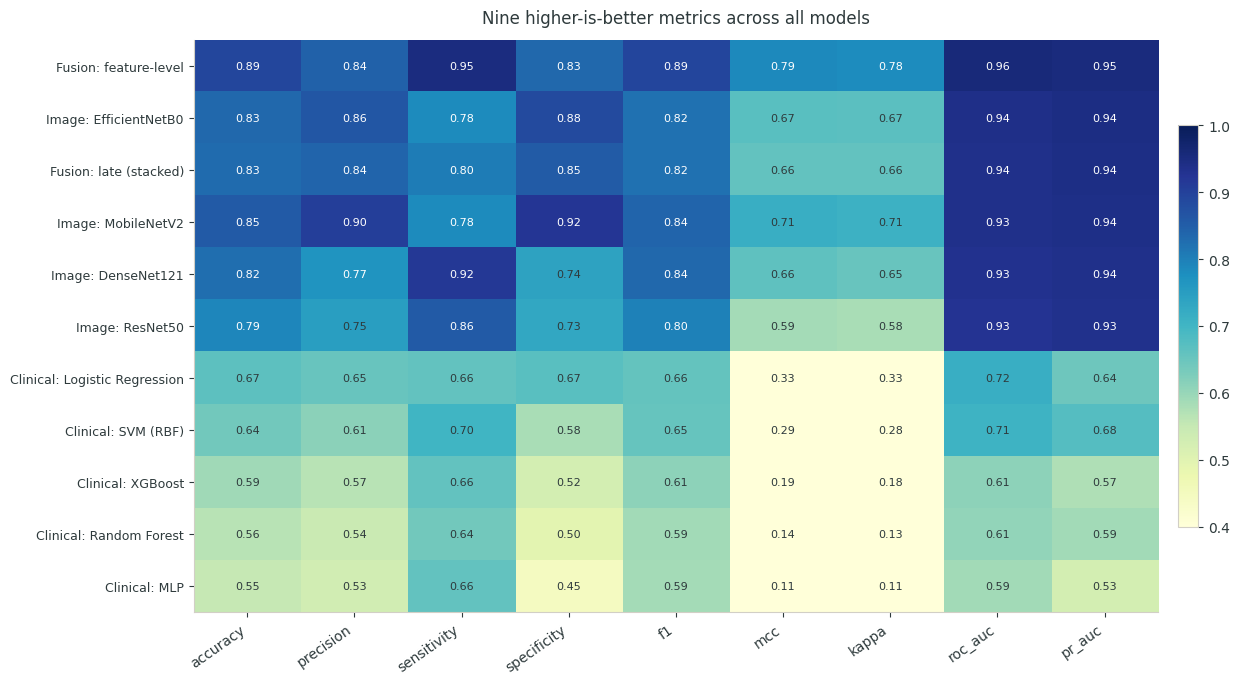

In [22]:
# ---- chart 1: metric heatmap across all models ----
hm_cols = ['accuracy','precision','sensitivity','specificity','f1','mcc','kappa','roc_auc','pr_auc']
hm = table.set_index('model')[hm_cols]

fig, ax = plt.subplots(figsize=(12.5, 0.45*len(hm)+2))
im = ax.imshow(hm.values, cmap='YlGnBu', vmin=0.4, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(hm_cols))); ax.set_xticklabels(hm_cols, rotation=35, ha='right')
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=9)
for i in range(len(hm)):
    for j in range(len(hm_cols)):
        v = hm.values[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.75 else PALETTE['ink'])
ax.set_title('Nine higher-is-better metrics across all models', pad=12)
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout(); plt.savefig(OUT/'fig_metric_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

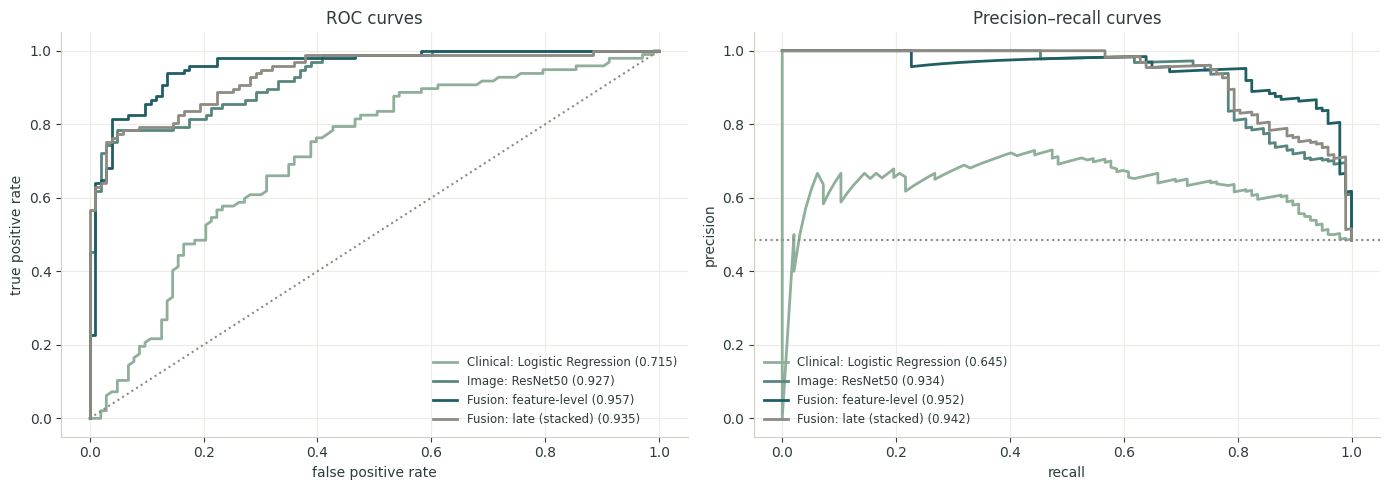

In [23]:
# ---- chart 2: ROC and precision-recall curves ----
test_y_lookup = (test_df.drop_duplicates('patient').set_index('patient')['label'] == 'Anaemic').astype(int)
headline = [BEST_CLINICAL, BEST_IMAGE, 'Fusion: feature-level', 'Fusion: late (stacked)']
colours  = [PALETTE['sage'], PALETTE['mid'], PALETTE['deep'], PALETTE['grey']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, c in zip(headline, colours):
    s = PROBS[name]; y = test_y_lookup.loc[s.index].to_numpy()
    fpr, tpr, _ = roc_curve(y, s.values)
    axes[0].plot(fpr, tpr, color=c, lw=2,
                 label=f'{name} ({roc_auc_score(y, s.values):.3f})')
    pr, rc, _ = precision_recall_curve(y, s.values)
    axes[1].plot(rc, pr, color=c, lw=2,
                 label=f'{name} ({average_precision_score(y, s.values):.3f})')

axes[0].plot([0,1],[0,1], ls=':', color=PALETTE['grey'])
axes[0].set_xlabel('false positive rate'); axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC curves'); axes[0].legend(fontsize=8.5, frameon=False, loc='lower right')

base_rate = test_y_lookup.loc[PROBS[headline[0]].index].mean()
axes[1].axhline(base_rate, ls=':', color=PALETTE['grey'])
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('Precision\u2013recall curves'); axes[1].legend(fontsize=8.5, frameon=False, loc='lower left')
plt.tight_layout(); plt.savefig(OUT/'fig_roc_pr_curves.png', dpi=150, bbox_inches='tight'); plt.show()

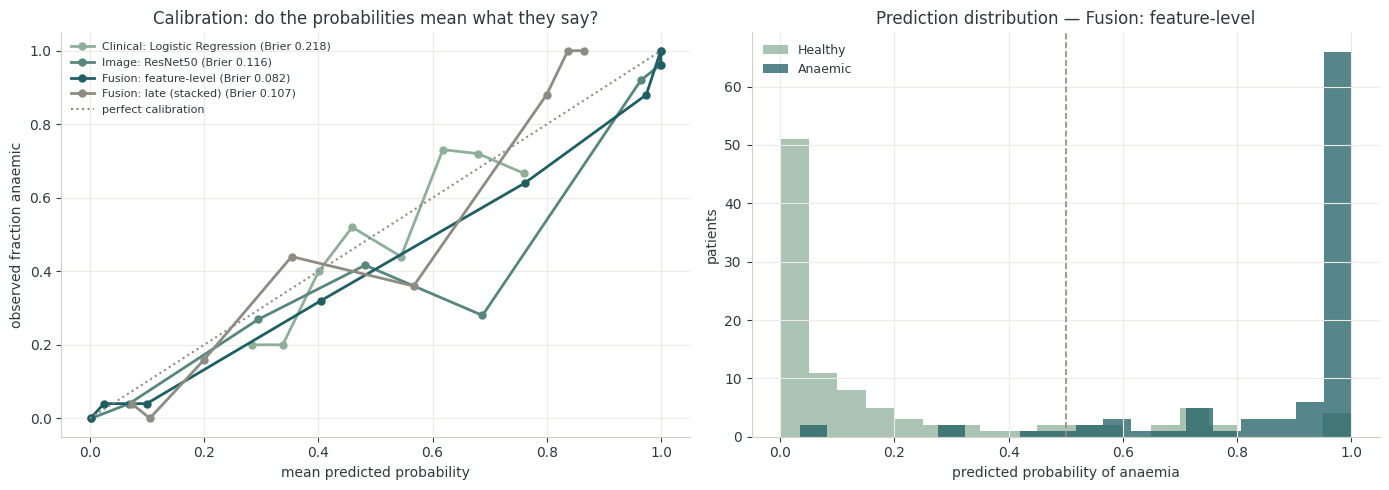

In [24]:
# ---- chart 3: calibration ----
test_y_lookup = (test_df.drop_duplicates('patient').set_index('patient')['label'] == 'Anaemic').astype(int)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, c in zip(headline, colours):
    s = PROBS[name]; y = test_y_lookup.loc[s.index].to_numpy()
    frac, mean_pred = calibration_curve(y, s.values, n_bins=8, strategy='quantile')
    axes[0].plot(mean_pred, frac, 'o-', color=c, lw=2, markersize=5,
                 label=f'{name} (Brier {brier_score_loss(y, s.values):.3f})')
axes[0].plot([0,1],[0,1], ls=':', color=PALETTE['grey'], label='perfect calibration')
axes[0].set_xlabel('mean predicted probability'); axes[0].set_ylabel('observed fraction anaemic')
axes[0].set_title('Calibration: do the probabilities mean what they say?')
axes[0].legend(fontsize=8, frameon=False, loc='upper left')

# predicted-probability distributions for the best model
s = PROBS[TOP_TEST_MODEL]; y = test_y_lookup.loc[s.index].to_numpy()
axes[1].hist(s.values[y==0], bins=20, alpha=0.75, color=PALETTE['sage'], label='Healthy')
axes[1].hist(s.values[y==1], bins=20, alpha=0.75, color=PALETTE['deep'], label='Anaemic')
axes[1].axvline(0.5, color=PALETTE['grey'], ls='--', lw=1.2)
axes[1].set_xlabel('predicted probability of anaemia'); axes[1].set_ylabel('patients')
axes[1].set_title(f'Prediction distribution \u2014 {TOP_TEST_MODEL}')
axes[1].legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.savefig(OUT/'fig_calibration.png', dpi=150, bbox_inches='tight'); plt.show()

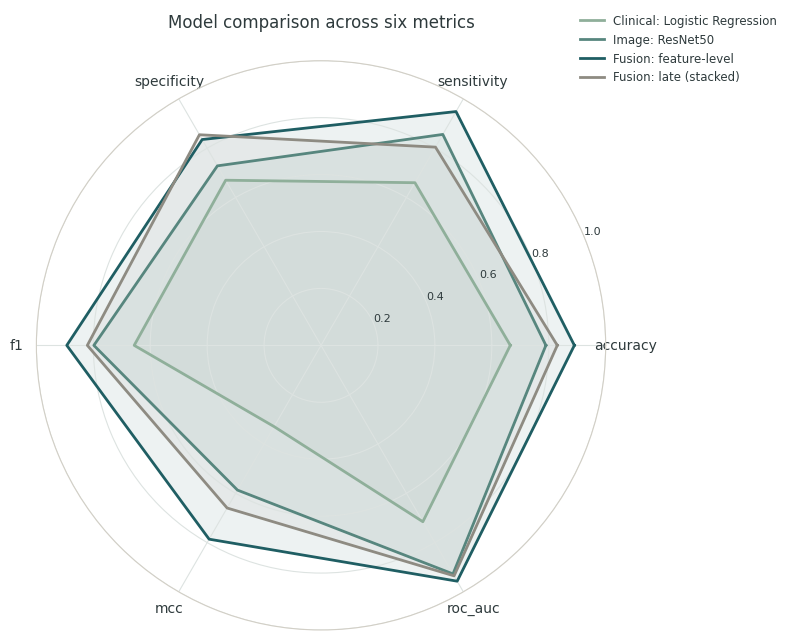

In [25]:
# ---- chart 4: radar comparison ----
radar_metrics = ['accuracy','sensitivity','specificity','f1','mcc','roc_auc']
angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7), subplot_kw={'polar': True})
for name, c in zip(headline, colours):
    vals = [RESULTS[name][m] for m in radar_metrics]; vals += vals[:1]
    ax.plot(angles, vals, color=c, lw=2, label=name)
    ax.fill(angles, vals, color=c, alpha=0.08)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.set_title('Model comparison across six metrics', pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.10), fontsize=8.5, frameon=False)
ax.grid(color='#DDE3E1')
plt.tight_layout(); plt.savefig(OUT/'fig_radar.png', dpi=150, bbox_inches='tight'); plt.show()

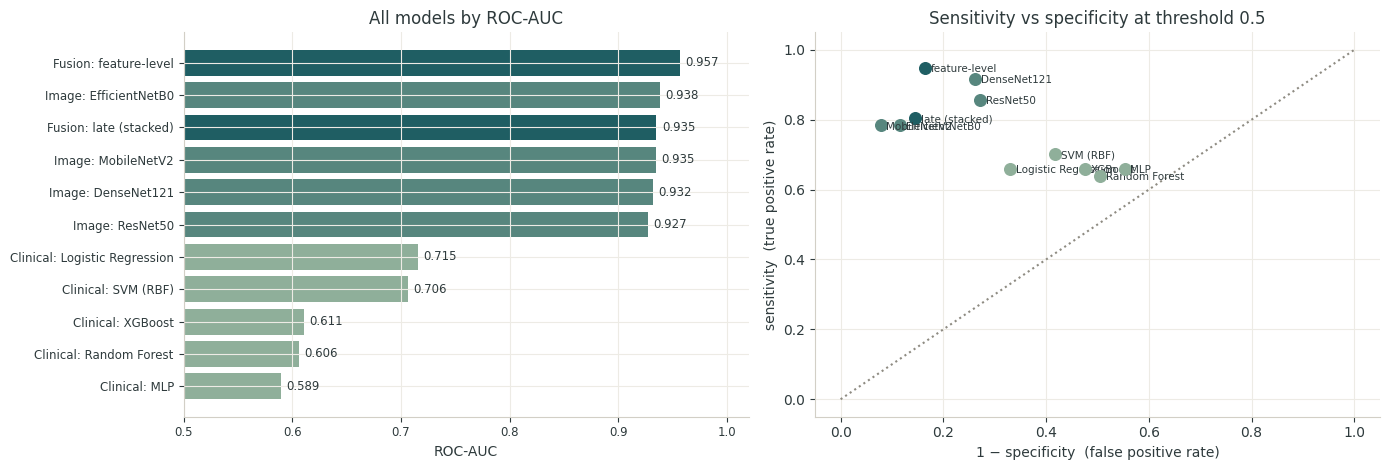

In [26]:
# ---- chart 5: per-arm summary and sensitivity/specificity trade-off ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

arm_of = lambda n: n.split(':')[0]
table['arm'] = table['model'].map(arm_of)
arm_colours = {'Clinical':PALETTE['sage'], 'Image':PALETTE['mid'], 'Fusion':PALETTE['deep']}

srt = table.sort_values('roc_auc')
axes[0].barh(srt['model'], srt['roc_auc'],
             color=[arm_colours[a] for a in srt['arm']])
for i,(m,v) in enumerate(zip(srt['model'], srt['roc_auc'])):
    axes[0].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8.5)
axes[0].set_xlim(0.5, 1.02); axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('All models by ROC-AUC'); axes[0].tick_params(labelsize=8.5)

for _, r in table.iterrows():
    axes[1].scatter(1-r['specificity'], r['sensitivity'],
                    color=arm_colours[r['arm']], s=70, zorder=3)
    axes[1].annotate(r['model'].split(': ')[-1], (1-r['specificity'], r['sensitivity']),
                     fontsize=7.5, xytext=(4,-3), textcoords='offset points')
axes[1].plot([0,1],[0,1], ls=':', color=PALETTE['grey'])
axes[1].set_xlabel('1 \u2212 specificity  (false positive rate)')
axes[1].set_ylabel('sensitivity  (true positive rate)')
axes[1].set_title('Sensitivity vs specificity at threshold 0.5')
plt.tight_layout(); plt.savefig(OUT/'fig_arm_summary.png', dpi=150, bbox_inches='tight'); plt.show()

---
# 9. Statistical comparison

McNemar's exact test compares the pre-specified headline models on the same 200 patients. It tests
paired classification errors at the 0.5 threshold; it is not a statistical test of ROC-AUC. Holm
adjustment is reported across the six headline comparisons to make the multiple-testing treatment
explicit.


In [27]:
from scipy.stats import binomtest
from itertools import combinations

def mcnemar(y, a, b, na, nb):
    ac, bc = (a == y), (b == y)
    a_only = int(np.sum(ac & ~bc)); b_only = int(np.sum(~ac & bc))
    n = a_only + b_only
    p = 1.0 if n == 0 else float(binomtest(a_only, n, 0.5).pvalue)
    return {'model_A':na, 'model_B':nb, 'A_only_correct':a_only,
            'B_only_correct':b_only, 'p_value':p}

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    m = len(p_values)
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * p_values[idx])
        adjusted[idx] = min(1.0, running)
    return adjusted

common = sorted(set.intersection(*[set(PROBS[n].index) for n in headline]))
test_label_lookup = (test_df.drop_duplicates('patient').set_index('patient')['label'] == 'Anaemic').astype(int)
y_cmp = test_label_lookup.loc[common].to_numpy()
preds = {n: (PROBS[n].loc[common].values >= 0.5).astype(int) for n in headline}

tests = [mcnemar(y_cmp, preds[a], preds[b], a, b) for a, b in combinations(headline, 2)]
mc = pd.DataFrame(tests)
mc['p_holm'] = holm_adjust(mc['p_value'])
mc['significant_holm_0.05'] = mc['p_holm'] < 0.05

print(f'Pairwise McNemar tests over {len(common)} shared patients:')
display(mc.assign(p_value=mc.p_value.round(4), p_holm=mc.p_holm.round(4)))
mc.to_csv(OUT/'mcnemar_extended.csv', index=False)


Pairwise McNemar tests over 200 shared patients:


,model_A,model_B,A_only_correct,B_only_correct,p_value,p_holm,significant_holm_0.05
0,Clinical: Logistic Regression,Image: ResNet50,29,54,0.0080,0.0241,True
1,Clinical: Logistic Regression,Fusion: feature-level,11,56,0.0000,0.0000,True
2,Clinical: Logistic Regression,Fusion: late (stacked),18,51,0.0001,0.0004,True
3,Image: ResNet50,Fusion: feature-level,4,24,0.0002,0.0007,True
4,Image: ResNet50,Fusion: late (stacked),5,13,0.0963,0.0963,False
5,Fusion: feature-level,Fusion: late (stacked),17,5,0.0169,0.0338,True


---
# 10. Interpretability: Grad-CAM

Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017) highlights regions associated
with a prediction. Two implementation corrections are required here.

**Class direction.** For a healthy prediction the target logit is negated, so the map represents
evidence for the predicted class rather than always showing evidence for anaemia.

**Sigmoid saturation.** Gradients are taken from the pre-sigmoid logit. Differentiating a saturated
probability can produce vanishing gradients and misleadingly blank maps.

Resolution is treated separately: the standard 224-pixel model gives a 7x7 final feature map, while
feeding a 448-pixel copy through the fully convolutional backbone gives a 14x14 localisation map
for visualisation only. All reported classification metrics still come from the 224-pixel model.


In [28]:
def last_conv_layer(base, min_spatial=1):
    """Deepest 4-D layer whose feature map is at least min_spatial x min_spatial."""
    for layer in reversed(base.layers):
        try:
            sh = layer.output.shape
            if len(sh) == 4 and sh[1] is not None and sh[1] >= min_spatial:
                return layer.name
        except AttributeError:
            continue
    return None

best = image_store[BEST_BACKBONE]
deep_layer = last_conv_layer(best['base'])
fine_layer = last_conv_layer(best['base'], 14)
print(f"Backbone: {BEST_BACKBONE}")
print(f"  deepest layer : {deep_layer}  {best['base'].get_layer(deep_layer).output.shape}")
print(f"  finer layer   : {fine_layer}  {best['base'].get_layer(fine_layer).output.shape}")


Backbone: ResNet50
  deepest layer : conv5_block3_out  (None, 7, 7, 2048)
  finer layer   : conv4_block6_out  (None, 14, 14, 1024)


coarse grid 7x7   |   fine grid 14x14
  Anaemic  p=1.00  coarse max=1.00 mean=0.52  |  fine max=1.00 mean=0.22
  Anaemic  p=1.00  coarse max=1.00 mean=0.56  |  fine max=1.00 mean=0.22
  Healthy  p=0.00  coarse max=1.00 mean=0.46  |  fine max=1.00 mean=0.25
  Healthy  p=0.00  coarse max=1.00 mean=0.48  |  fine max=1.00 mean=0.33
  Anaemic  p=0.05  coarse max=1.00 mean=0.21  |  fine max=1.00 mean=0.22
  Anaemic  p=0.10  coarse max=1.00 mean=0.18  |  fine max=1.00 mean=0.15


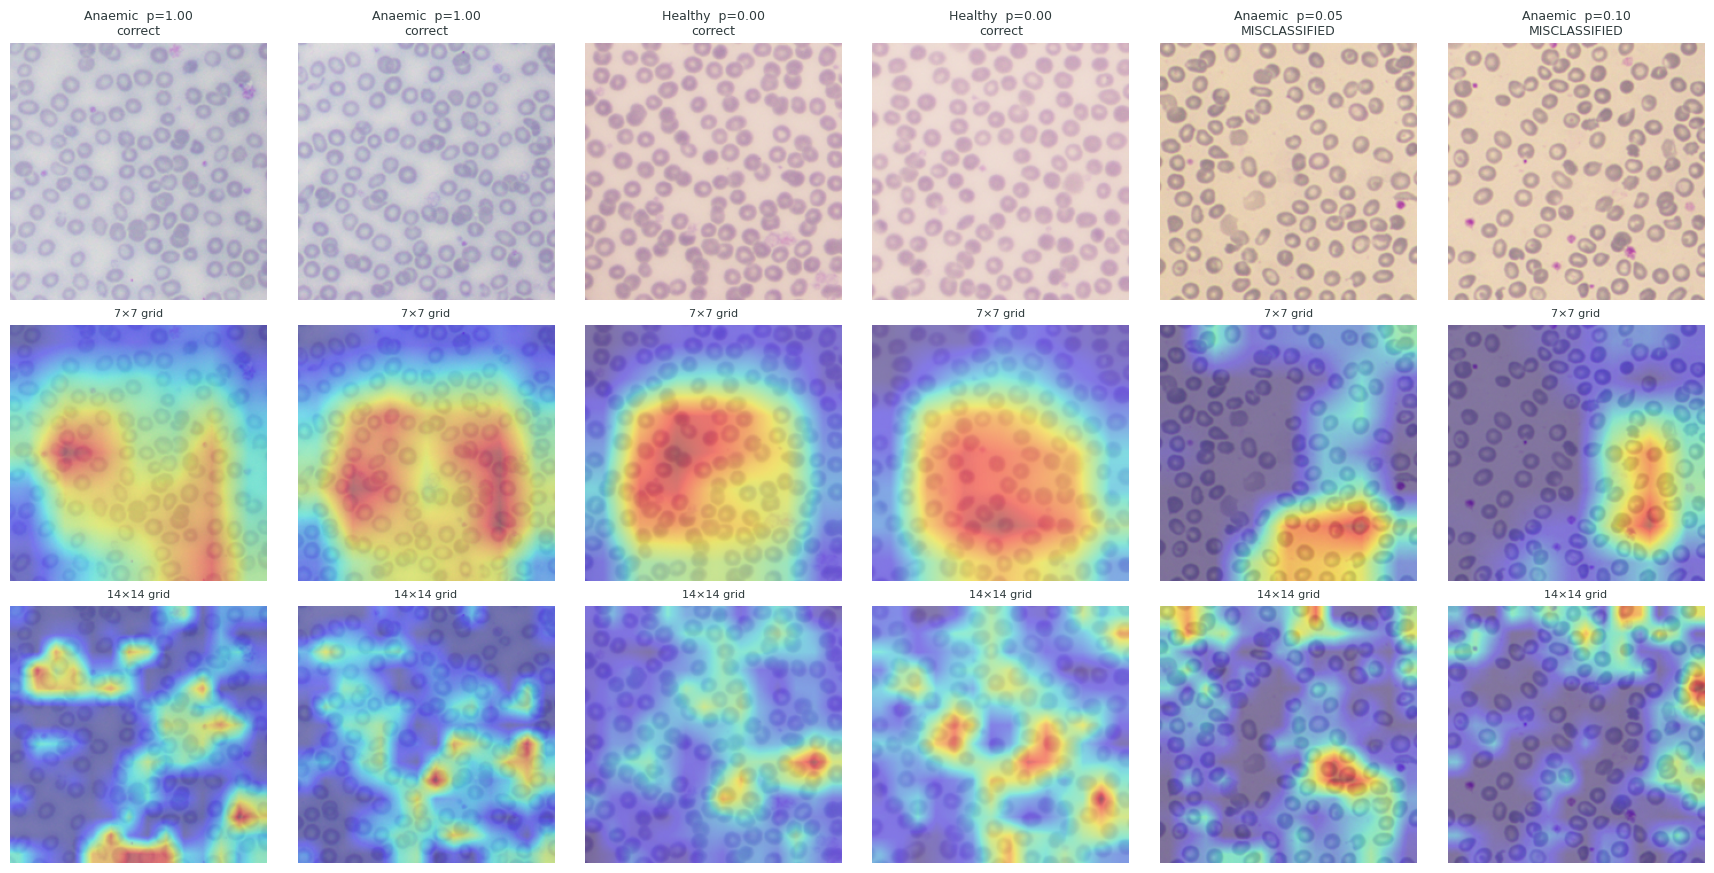

Row 1: input   |   Row 2: 224px input   |   Row 3: 448px input (finer localisation)


In [29]:
# ---- Grad-CAM heatmaps at two resolutions ----

# select examples: confident correct anaemic, confident correct healthy, and misclassified
te = test_df.assign(prob=best['model'].predict(image_ds(test_df), verbose=0).ravel())
te['y'] = (te.label == 'Anaemic').astype(int)
te['correct'] = (te.prob >= 0.5).astype(int) == te.y

picks = pd.concat([
    te[(te.y == 1) & te.correct].nlargest(2, 'prob'),     # confident, correct anaemic
    te[(te.y == 0) & te.correct].nsmallest(2, 'prob'),    # confident, correct healthy
    te[~te.correct].head(2),                              # misclassified
])
imgs = np.stack([np.array(Image.open(p).resize((CFG['img_size'],) * 2).convert('RGB'),
                          dtype='float32') for p in picks['path']])
predicted_cls = (picks['prob'] >= 0.5).astype(int).values


def gradcam_at_scale(model, base, imgs_raw, class_index, scale=1):
    """Grad-CAM from the final convolutional block.

    Two corrections over a naive implementation:

    1. Gradients are taken of the PRE-SIGMOID LOGIT, not the probability. At p close to
       1.0 the sigmoid is flat, its derivative vanishes, and the resulting heatmap is
       noise. The final Dense layer is therefore rebuilt with a linear activation using
       the same weights.
    2. The target is negated for healthy predictions, so each map shows evidence for the
       class actually predicted rather than always showing evidence for anaemia.

    A finer grid comes from enlarging the input rather than tapping an earlier layer:
    the backbone is fully convolutional, so 448px yields a 14x14 map with the same
    channel count and the trained head can be reused unchanged.
    """
    S = CFG['img_size'] * scale
    ctor, prep = BACKBONES[BEST_BACKBONE]

    if scale == 1:
        big = base
    else:
        big = ctor(include_top=False, weights=None, input_shape=(S, S, 3))
        big.set_weights(base.get_weights())    # conv kernels are independent of input size

    conv_name = last_conv_layer(big)
    feat = keras.Model(big.inputs, big.get_layer(conv_name).output)

    # rebuild the head with a LINEAR final layer so we differentiate the logit
    idx = next(i for i, l in enumerate(model.layers) if l is base)
    hin = keras.Input(shape=feat.output.shape[1:])
    h = hin
    for l in model.layers[idx + 1:]:
        if isinstance(l, layers.Dense) and getattr(l.activation, '__name__', '') == 'sigmoid':
            lin = layers.Dense(l.units, activation=None, name='logit')
            lin.build(h.shape)
            lin.set_weights(l.get_weights())   # same weights, no squashing
            h = lin(h)
        else:
            h = l(h)
    head = keras.Model(hin, h)                 # outputs logits

    x = tf.image.resize(tf.cast(imgs_raw, tf.float32), [S, S])
    x = prep(x)
    with tf.GradientTape() as tape:
        fmap = feat(x, training=False)
        tape.watch(fmap)
        logit = head(fmap, training=False)
        target = logit[:, 0]
        sign = tf.constant([1.0 if c == 1 else -1.0 for c in class_index], dtype=tf.float32)
        target = target * sign

    grads = tape.gradient(target, fmap)
    w = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.nn.relu(tf.reduce_sum(fmap * w[:, None, None, :], axis=-1))
    cam = cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)
    return cam.numpy(), tf.sigmoid(logit).numpy().ravel()


cam_d, _ = gradcam_at_scale(best['model'], best['base'], imgs, predicted_cls, scale=1)  # coarse
cam_f, _ = gradcam_at_scale(best['model'], best['base'], imgs, predicted_cls, scale=2)  # fine
print(f'coarse grid {cam_d.shape[1]}x{cam_d.shape[2]}   |   '
      f'fine grid {cam_f.shape[1]}x{cam_f.shape[2]}')

# sanity check: every map should contain a genuine bright region
for i, (_, row) in enumerate(picks.iterrows()):
    print(f"  {row['label']:8s} p={row['prob']:.2f}  "
          f"coarse max={cam_d[i].max():.2f} mean={cam_d[i].mean():.2f}  |  "
          f"fine max={cam_f[i].max():.2f} mean={cam_f[i].mean():.2f}")

fig, axes = plt.subplots(3, len(picks), figsize=(2.9 * len(picks), 8.8))
for i, (_, row) in enumerate(picks.iterrows()):
    axes[0, i].imshow(imgs[i].astype('uint8')); axes[0, i].axis('off')
    axes[0, i].set_title(f"{row['label']}  p={row['prob']:.2f}\n"
                         f"{'correct' if row['correct'] else 'MISCLASSIFIED'}", fontsize=9)
    for r, cam in [(1, cam_d), (2, cam_f)]:
        heat = tf.image.resize(cam[i][..., None], [CFG['img_size']] * 2).numpy().squeeze()
        axes[r, i].imshow(imgs[i].astype('uint8'))
        axes[r, i].imshow(heat, cmap='jet', alpha=0.45)
        axes[r, i].axis('off')
        axes[r, i].set_title(f'{cam.shape[1]}\u00d7{cam.shape[2]} grid', fontsize=8)

plt.tight_layout(); plt.savefig(OUT / 'fig_gradcam.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Row 1: input   |   Row 2: {CFG["img_size"]}px input   |   '
      f'Row 3: {CFG["img_size"]*2}px input (finer localisation)')

Attention alignment with dark-region proxy  (ratio 1.0 = uniform-attention reference)



,example,p,scale,mass_on_proxy,proxy_area,ratio
0,Anaemic,1.00,224px,0.454,0.437,1.04
1,Anaemic,1.00,448px,0.518,0.437,1.18
2,Anaemic,1.00,224px,0.477,0.448,1.06
3,Anaemic,1.00,448px,0.520,0.448,1.16
4,Healthy,0.00,224px,0.462,0.455,1.02
5,Healthy,0.00,448px,0.472,0.455,1.04
6,Healthy,0.00,224px,0.462,0.451,1.03
7,Healthy,0.00,448px,0.472,0.451,1.05
8,Anaemic (wrong),0.05,224px,0.473,0.454,1.04
9,Anaemic (wrong),0.05,448px,0.515,0.454,1.14



Mean ratio by scale:


,mean,min,max
scale,,,
224px,1.06,1.02,1.14
448px,1.12,1.04,1.18


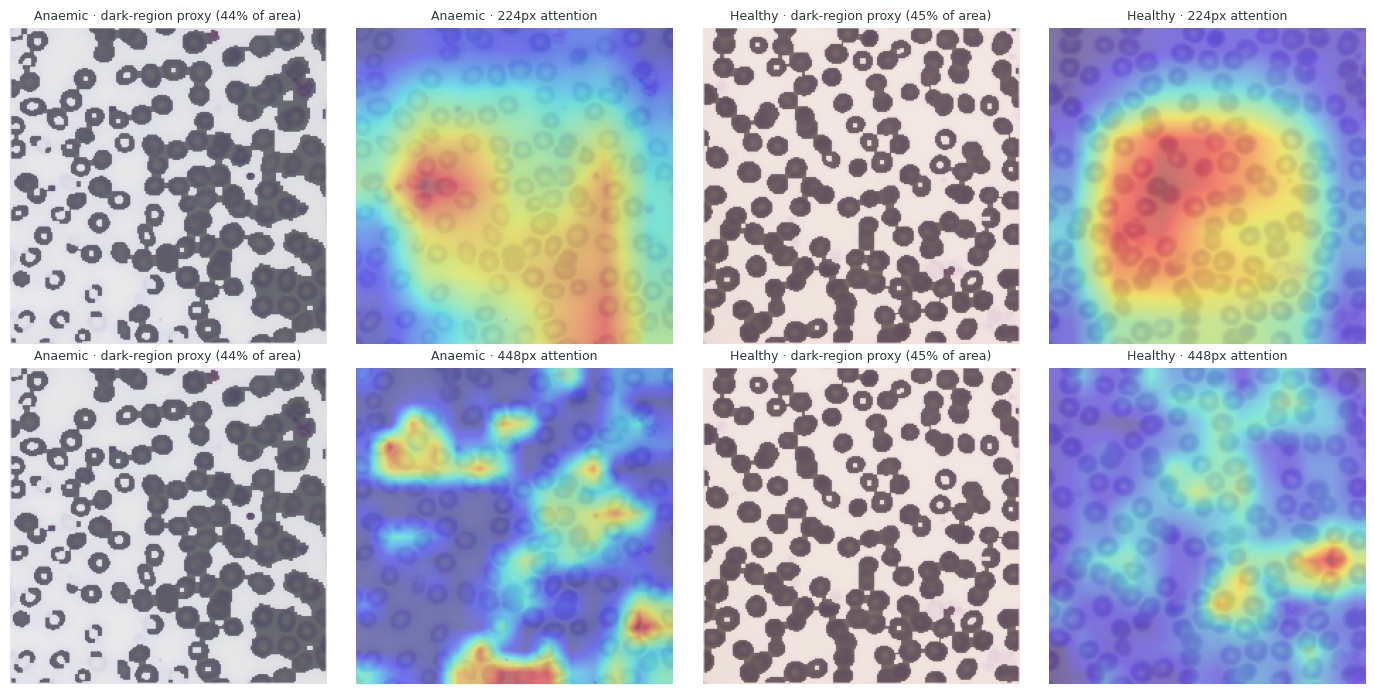


Mean alignment ratio at 448px: 1.12
A ratio above 1 means more heatmap mass fell inside the proxy than under uniform
attention; it does not validate the proxy or establish morphology use.
Scope note: this summary uses six deliberately selected examples for visual
diagnosis. Treat it as exploratory; an inferential claim would require a
pre-specified larger sample, validated masks, and an interval or statistical test.


In [30]:

# ratio = (heatmap mass on cells) / (fraction of image occupied by cells)
#   1.0  attention spread exactly as cells are, the uniform-attention reference
#  >1.0  the model attends to cells more than the uniform reference

from scipy import ndimage

def cell_mask(img, percentile=45):
    grey = img.mean(axis=2)
    m = grey < np.percentile(grey, percentile)
    m = ndimage.binary_opening(m, np.ones((3, 3)))    # drop specks
    m = ndimage.binary_closing(m, np.ones((3, 3)))    # fill pinholes
    return m

def attention_on_cells(cam, img):
    heat = tf.image.resize(cam[..., None], img.shape[:2]).numpy().squeeze()
    heat = heat / (heat.sum() + 1e-8)
    mask = cell_mask(img)
    mass, area = heat[mask].sum(), mask.mean()
    return mass, area, mass / (area + 1e-8)

rows = []
for i, (_, row) in enumerate(picks.iterrows()):
    for scale_name, cam in [('224px', cam_d), ('448px', cam_f)]:
        mass, area, ratio = attention_on_cells(cam[i], imgs[i])
        rows.append({'example': f"{row['label']}{' (wrong)' if not row['correct'] else ''}",
                     'p': round(row['prob'], 2), 'scale': scale_name,
                     'mass_on_proxy': round(mass, 3), 'proxy_area': round(area, 3),
                     'ratio': round(ratio, 2)})

align = pd.DataFrame(rows)
print('Attention alignment with dark-region proxy  (ratio 1.0 = uniform-attention reference)\n')
display(align)
print('\nMean ratio by scale:')
display(align.groupby('scale')['ratio'].agg(['mean', 'min', 'max']).round(2))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for r, (scale_name, cam) in enumerate([('224px', cam_d), ('448px', cam_f)]):
    for c, i in enumerate([0, 2]):
        img = imgs[i]
        heat = tf.image.resize(cam[i][..., None], img.shape[:2]).numpy().squeeze()
        mask = cell_mask(img)
        axes[r, c*2].imshow(img.astype('uint8'))
        axes[r, c*2].imshow(mask, cmap='Greys', alpha=0.45)
        axes[r, c*2].set_title(f"{picks.iloc[i]['label']} · dark-region proxy "
                               f"({mask.mean()*100:.0f}% of area)", fontsize=9)
        axes[r, c*2+1].imshow(img.astype('uint8'))
        axes[r, c*2+1].imshow(heat, cmap='jet', alpha=0.45)
        axes[r, c*2+1].set_title(f"{picks.iloc[i]['label']} · {scale_name} attention", fontsize=9)
        for a in (axes[r, c*2], axes[r, c*2+1]):
            a.axis('off')
plt.tight_layout()
plt.savefig(OUT/'fig_attention_alignment.png', dpi=150, bbox_inches='tight'); plt.show()

mean_ratio = align[align.scale == '448px']['ratio'].mean()
print(f'\nMean alignment ratio at 448px: {mean_ratio:.2f}')
print('A ratio above 1 means more heatmap mass fell inside the proxy than under uniform')
print('attention; it does not validate the proxy or establish morphology use.')
print('Scope note: this summary uses six deliberately selected examples for visual')
print('diagnosis. Treat it as exploratory; an inferential claim would require a')
print('pre-specified larger sample, validated masks, and an interval or statistical test.')


---
# 11. Diagnostic: low-level image signal and colour sensitivity

The heatmaps motivate a direct test of what can be achieved without explicit spatial morphology.
The first baseline uses nine global colour/contrast summaries. These discard spatial arrangement
and explicit shape descriptors, although channel variability can still reflect aggregate cell
density or packing. The second diagnostic converts the held-out images to greyscale and evaluates
the already-trained model. Because greyscale images are out of the training distribution, this is a
sensitivity analysis rather than a clean causal ablation.


In [33]:
# ---- test 1: how far can global colour/contrast summaries get? ----
from sklearn.linear_model import LogisticRegression as LR_
from sklearn.ensemble import RandomForestClassifier as RF_

def colour_features(path, size=64):
    """Nine global colour/contrast summaries; no spatial arrangement or explicit shape descriptors."""
    im = np.asarray(Image.open(path).resize((size,size)).convert('RGB'), dtype=np.float32)/255.0
    f = []
    for c in range(3):
        f += [im[:,:,c].mean(), im[:,:,c].std()]
    hsv = np.asarray(Image.open(path).resize((size,size)).convert('HSV'), dtype=np.float32)/255.0
    for c in range(3):
        f.append(hsv[:,:,c].mean())
    return f

COLNAMES = ['R_mean','R_std','G_mean','G_std','B_mean','B_std','H_mean','S_mean','V_mean']

samp_tr = train_df.groupby('label', group_keys=False).apply(
    lambda d: d.sample(min(1200, len(d)), random_state=SEED))
print(f'Extracting colour features: {len(samp_tr)} train, {len(test_df)} test images...')
Xc_tr = np.array([colour_features(p) for p in samp_tr['path']])
Xc_te = np.array([colour_features(p) for p in test_df['path']])
yc_tr = (samp_tr.label=='Anaemic').astype(int).values
yc_te = (test_df.label=='Anaemic').astype(int).values

colour_rows = []
for nm, clf in [('Logistic Regression', LR_(max_iter=2000, random_state=SEED)),
                ('Random Forest', RF_(n_estimators=300, random_state=SEED, n_jobs=-1))]:
    m = Pipeline([('sc', StandardScaler()), ('clf', clf)]).fit(Xc_tr, yc_tr)
    prob = m.predict_proba(Xc_te)[:,1]
    pt = (test_df.assign(prob=prob, y=yc_te)
                 .groupby('patient').agg(prob=('prob','mean'), y=('y','first')))
    r = evaluate(pt['y'], pt['prob'], name=f'Colour only: {nm}')
    colour_rows.append(r); show(r)

colour_auc = max(r['roc_auc'] for r in colour_rows)
image_auc  = RESULTS[BEST_IMAGE]['roc_auc']
print(f'\nBest image model AUC : {image_auc:.3f}')
print(f'Colour-only AUC      : {colour_auc:.3f}')
print(f'Gap                  : {image_auc - colour_auc:+.3f}')

Extracting colour features: 2400 train, 2400 test images...
--- Colour only: Logistic Regression ---
   accuracy=0.750  precision=0.758  sensitivity=0.711  specificity=0.786  f1=0.734  mcc=0.500  kappa=0.499  roc_auc=0.814  pr_auc=0.824  brier=0.190
--- Colour only: Random Forest ---
   accuracy=0.835  precision=0.856  sensitivity=0.794  specificity=0.874  f1=0.824  mcc=0.671  kappa=0.669  roc_auc=0.929  pr_auc=0.940  brier=0.110

Best image model AUC : 0.927
Colour-only AUC      : 0.929
Gap                  : -0.002


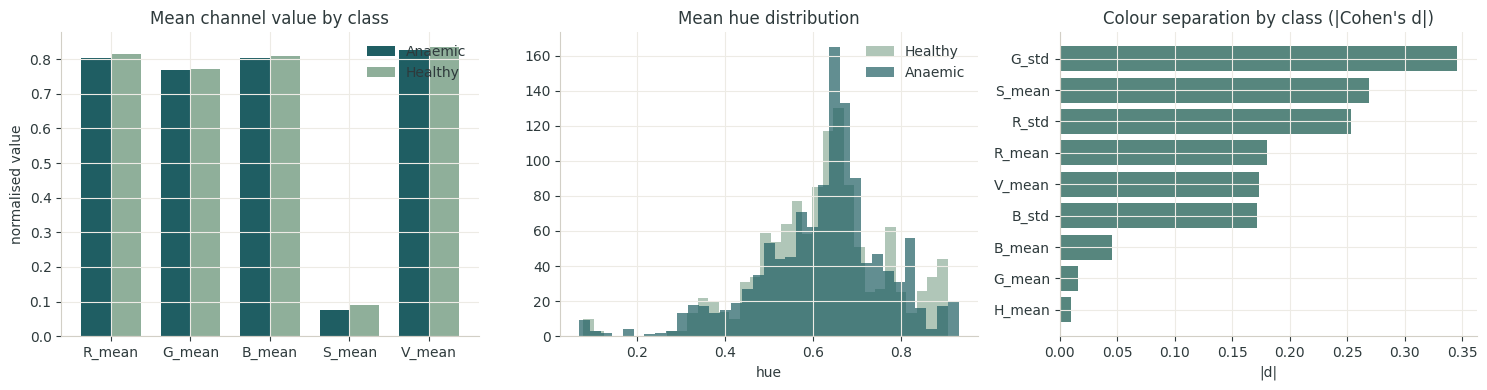

,feature,abs_d
0,G_std,0.346
1,S_mean,0.269
2,R_std,0.253
3,R_mean,0.180
4,V_mean,0.174
5,B_std,0.171
6,B_mean,0.046
7,G_mean,0.016
8,H_mean,0.010


In [35]:
# ---- where does the colour difference sit? ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

means = pd.DataFrame(Xc_tr, columns=COLNAMES).assign(label=samp_tr['label'].values)
grp = means.groupby('label')[['R_mean','G_mean','B_mean','S_mean','V_mean']].mean()
grp.T.plot.bar(ax=axes[0], color=[PALETTE['deep'], PALETTE['sage']], rot=0, width=0.75)
axes[0].set_title('Mean channel value by class'); axes[0].set_ylabel('normalised value')
axes[0].legend(title=None, frameon=False)

for lab, c in [('Healthy', PALETTE['sage']), ('Anaemic', PALETTE['deep'])]:
    axes[1].hist(means.loc[means.label==lab, 'H_mean'], bins=35, alpha=0.7, label=lab, color=c)
axes[1].set_title('Mean hue distribution'); axes[1].set_xlabel('hue'); axes[1].legend(frameon=False)

sep = []
for col in COLNAMES:
    a = means.loc[means.label=='Anaemic', col]; h = means.loc[means.label=='Healthy', col]
    p = np.sqrt(((len(a)-1)*a.var() + (len(h)-1)*h.var()) / (len(a)+len(h)-2))
    sep.append({'feature': col, 'abs_d': abs((a.mean()-h.mean())/p) if p else 0})
sep = pd.DataFrame(sep).sort_values('abs_d')
axes[2].barh(sep['feature'], sep['abs_d'], color=PALETTE['mid'])
axes[2].set_title("Colour separation by class (|Cohen's d|)"); axes[2].set_xlabel('|d|')

plt.tight_layout(); plt.savefig(OUT/'fig_colour_confound.png', dpi=150, bbox_inches='tight'); plt.show()
display(sep.sort_values('abs_d', ascending=False).round(3).reset_index(drop=True))

In [36]:
# ---- test 2: does performance survive colour removal? ----
def grey_ds(df):
    paths  = df['path'].values
    labels = (df['label']=='Anaemic').astype('float32').values
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [CFG['img_size']]*2)
        img = tf.image.rgb_to_grayscale(img)      # destroy colour
        img = tf.image.grayscale_to_rgb(img)      # restore 3 channels
        img.set_shape([CFG['img_size'], CFG['img_size'], 3])
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    return ds.map(load, num_parallel_calls=AUTOTUNE).batch(CFG['batch_size']).prefetch(AUTOTUNE)

grey_prob = best['model'].predict(grey_ds(test_df), verbose=0).ravel()
pt_grey = to_patient(test_df, grey_prob)
r_grey = evaluate(pt_grey['y'], pt_grey['prob'], name=f'{BEST_BACKBONE} on greyscale')
show(r_grey)

cmp = pd.DataFrame([
  {'input':'Original colour', **{k: RESULTS[BEST_IMAGE][k]
                                 for k in ['accuracy','sensitivity','specificity','roc_auc']}},
  {'input':'Greyscale (colour removed)', **{k: r_grey[k]
                                 for k in ['accuracy','sensitivity','specificity','roc_auc']}},
]).round(3)
display(cmp)

drop = RESULTS[BEST_IMAGE]['roc_auc'] - r_grey['roc_auc']
sens_drop = RESULTS[BEST_IMAGE]['sensitivity'] - r_grey['sensitivity']
print(f'\nAUC drop when colour is removed: {drop:+.3f}')
print(f'Sensitivity drop at threshold 0.5: {sens_drop:+.3f}\n')
print('Interpretation: ranking performance is partly retained, but the operating point shifts')
print('substantially. Because greyscale inputs are out of distribution, this diagnostic cannot')
print('by itself distinguish colour reliance from distribution shift. Interpret it together')
print('with the global-statistics baseline and avoid claiming either pure morphology or a')
print('pure staining confound from this test alone.')


--- ResNet50 on greyscale ---
   accuracy=0.815  precision=0.849  sensitivity=0.753  specificity=0.874  f1=0.798  mcc=0.632  kappa=0.628  roc_auc=0.903  pr_auc=0.907  brier=0.128


,input,accuracy,sensitivity,specificity,roc_auc
0,Original colour,0.790,0.856,0.728,0.927
1,Greyscale (colour removed),0.815,0.753,0.874,0.903



AUC drop when colour is removed: +0.024
Sensitivity drop at threshold 0.5: +0.103

Interpretation: ranking performance is partly retained, but the operating point shifts
substantially. Because greyscale inputs are out of distribution, this diagnostic cannot
by itself distinguish colour reliance from distribution shift. Interpret it together
with the global-statistics baseline and avoid claiming either pure morphology or a
pure staining confound from this test alone.


**Report whatever this produces, including an unfavourable result.** A study that identifies a
possible confound in its own data and measures it is more credible than one that reports high
accuracy and never asks the question. If a staining difference is present, that is a finding about
the AneRBC dataset in its own right, and it would help explain the high accuracies reported in the
published baselines.

---
# 12. Export

In [37]:
summary = {
    'config': CFG, 'seed': SEED,
    'n_models': len(RESULTS),
    'selected_clinical_by_development_cv': BEST_CLINICAL,
    'selected_image_by_validation_auc': BEST_IMAGE,
    'top_test_model_descriptive': TOP_TEST_MODEL,
    'metric_count': 10,
    'validation_image': {k: v for k, v in VAL_RESULTS.items()},
    'results': {k: {kk: (float(vv) if isinstance(vv,(int,float,np.floating,np.integer)) else vv)
                    for kk, vv in v.items()} for k, v in RESULTS.items()},
    'cv_clinical': cv_clinical.to_dict('records'),
    'mcnemar': mc.to_dict('records'),
    'training_minutes': {k: v['minutes'] for k, v in histories.items()},
}
with open(OUT/'results_extended.json','w') as f:
    json.dump(summary, f, indent=2, default=str)

pd.DataFrame(PROBS).to_csv(OUT/'patient_probabilities_all_models.csv')

print('Files written:')
for f in sorted(OUT.glob('*')):
    if f.is_file(): print(f'  {f.name:<45s} {f.stat().st_size/1024:>8.1f} KB')

print('\n' + '='*70)
print('FINAL RANKING — 200 held-out patients')
print('='*70)
display(table_r[['model','accuracy','sensitivity','specificity','f1','mcc','roc_auc','pr_auc']])

Files written:
  ablation_clinical_branch.csv                       0.2 KB
  ablation_mcnemar.csv                               0.3 KB
  cbc_effect_sizes.csv                               0.6 KB
  cleaning_audit.csv                                 0.2 KB
  clinical_data_sample.csv                           0.5 KB
  fig_arm_summary.png                              141.4 KB
  fig_attention_alignment.png                     1964.3 KB
  fig_calibration.png                              159.7 KB
  fig_cbc_distributions.png                        115.9 KB
  fig_class_balance.png                             76.3 KB
  fig_clinical_data_sample.png                     274.9 KB
  fig_colour_confound.png                           81.4 KB
  fig_confusion_all.png                            133.2 KB
  fig_gradcam.png                                 3280.7 KB
  fig_metric_heatmap.png                           183.2 KB
  fig_radar.png                                    205.0 KB
  fig_roc_pr_curves.png  

,model,accuracy,sensitivity,specificity,f1,mcc,roc_auc,pr_auc
0,Fusion: feature-level,0.890,0.948,0.835,0.893,0.786,0.957,0.952
1,Image: EfficientNetB0,0.835,0.784,0.883,0.822,0.672,0.938,0.944
2,Fusion: late (stacked),0.830,0.804,0.854,0.821,0.660,0.935,0.942
3,Image: MobileNetV2,0.855,0.784,0.922,0.840,0.715,0.935,0.941
4,Image: DenseNet121,0.825,0.918,0.738,0.836,0.664,0.932,0.935
5,Image: ResNet50,0.790,0.856,0.728,0.798,0.587,0.927,0.934
6,Clinical: Logistic Regression,0.665,0.660,0.670,0.656,0.330,0.715,0.645
7,Clinical: SVM (RBF),0.640,0.701,0.583,0.654,0.285,0.706,0.676
8,Clinical: XGBoost,0.590,0.660,0.524,0.610,0.186,0.611,0.575
9,Clinical: Random Forest,0.565,0.639,0.495,0.588,0.136,0.606,0.589


---
## What to report

- State that **ten metrics** were computed.
- Keep the clinical family and image backbone selections tied to development/validation results,
  never to the held-out test ranking.
- Do not write that feature-level fusion won on every metric. Report the trade-off: it led on
  accuracy, sensitivity, F1, MCC, kappa, ROC-AUC, PR-AUC and Brier score in v04, whereas late
  fusion had higher precision and specificity. Refresh this sentence after rerunning v05.1.
- Report McNemar results with their paired-error interpretation and Holm-adjusted values. A
  non-significant comparison does not establish equivalence.
- Describe the colour and Grad-CAM work as evidence of a possible low-level shortcut, not proof
  that the network learned no morphology. The six-example attention alignment is exploratory.
- Calibration, precision and PR-AUC are benchmark-specific because the test cohort is balanced;
  they are not deployment probabilities.


In [39]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from IPython.display import FileLink, display

working = Path("/kaggle/working")
zip_path = working / "anaemia_v06_high_resolution_assets.zip"

# Original saved figures
figure_files = sorted(working.glob("fig_*.png"))

# Useful result tables
extra_files = [
    working / "clinical_data_sample.csv",
    working / "results_all_models_extended.csv",
    working / "mcnemar_extended.csv",
    working / "cbc_effect_sizes.csv",
    working / "results_extended.json",
]

files_to_zip = figure_files + [f for f in extra_files if f.exists()]

if not figure_files:
    raise FileNotFoundError(
        "No original figures were found. Run the complete notebook first, "
        "then run this cell again."
    )

with ZipFile(zip_path, "w", ZIP_DEFLATED) as archive:
    for file in files_to_zip:
        archive.write(file, arcname=file.name)

print(f"Created: {zip_path.name}")
print(f"Included {len(figure_files)} high-resolution figures")
print(f"ZIP size: {zip_path.stat().st_size / (1024**2):.1f} MB")

display(FileLink(str(zip_path)))

Created: anaemia_v06_high_resolution_assets.zip
Included 14 high-resolution figures
ZIP size: 8.9 MB


/kaggle/working/anaemia_v06_high_resolution_assets.zip